In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_final= pd.read_csv(r"C:\AI-Based Smart City Air Quality Monitoring and Forecasting System for Greater Bilbao\data\processed\cleaned_air_quality_bilbao_2015_2026.csv")
df_final.head()

,Date,station,Town,Province,Latitude,Longitude,NO2,PM10,PM2.5,SO2
0,2015-01-01,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,47.0,25.0,28.0,9.0
1,2015-01-02,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,56.0,24.0,18.0,8.0
2,2015-01-03,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,48.0,33.0,21.0,8.0
3,2015-01-04,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,43.0,31.0,23.0,7.0
4,2015-01-05,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,29.0,18.0,11.0,5.0


In [3]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 27883 entries, 0 to 27882
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       27883 non-null  str    
 1   station    27883 non-null  str    
 2   Town       27883 non-null  str    
 3   Province   27883 non-null  str    
 4   Latitude   27883 non-null  float64
 5   Longitude  27883 non-null  float64
 6   NO2        27883 non-null  float64
 7   PM10       27883 non-null  float64
 8   PM2.5      27883 non-null  float64
 9   SO2        27883 non-null  float64
dtypes: float64(6), str(4)
memory usage: 2.1 MB


In [4]:
df_final["Date"] = pd.to_datetime(df_final["Date"])
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 27883 entries, 0 to 27882
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       27883 non-null  datetime64[us]
 1   station    27883 non-null  str           
 2   Town       27883 non-null  str           
 3   Province   27883 non-null  str           
 4   Latitude   27883 non-null  float64       
 5   Longitude  27883 non-null  float64       
 6   NO2        27883 non-null  float64       
 7   PM10       27883 non-null  float64       
 8   PM2.5      27883 non-null  float64       
 9   SO2        27883 non-null  float64       
dtypes: datetime64[us](1), float64(6), str(3)
memory usage: 2.1 MB


In [5]:
df_final.isnull().sum()

Date         0
station      0
Town         0
Province     0
Latitude     0
Longitude    0
NO2          0
PM10         0
PM2.5        0
SO2          0
dtype: int64

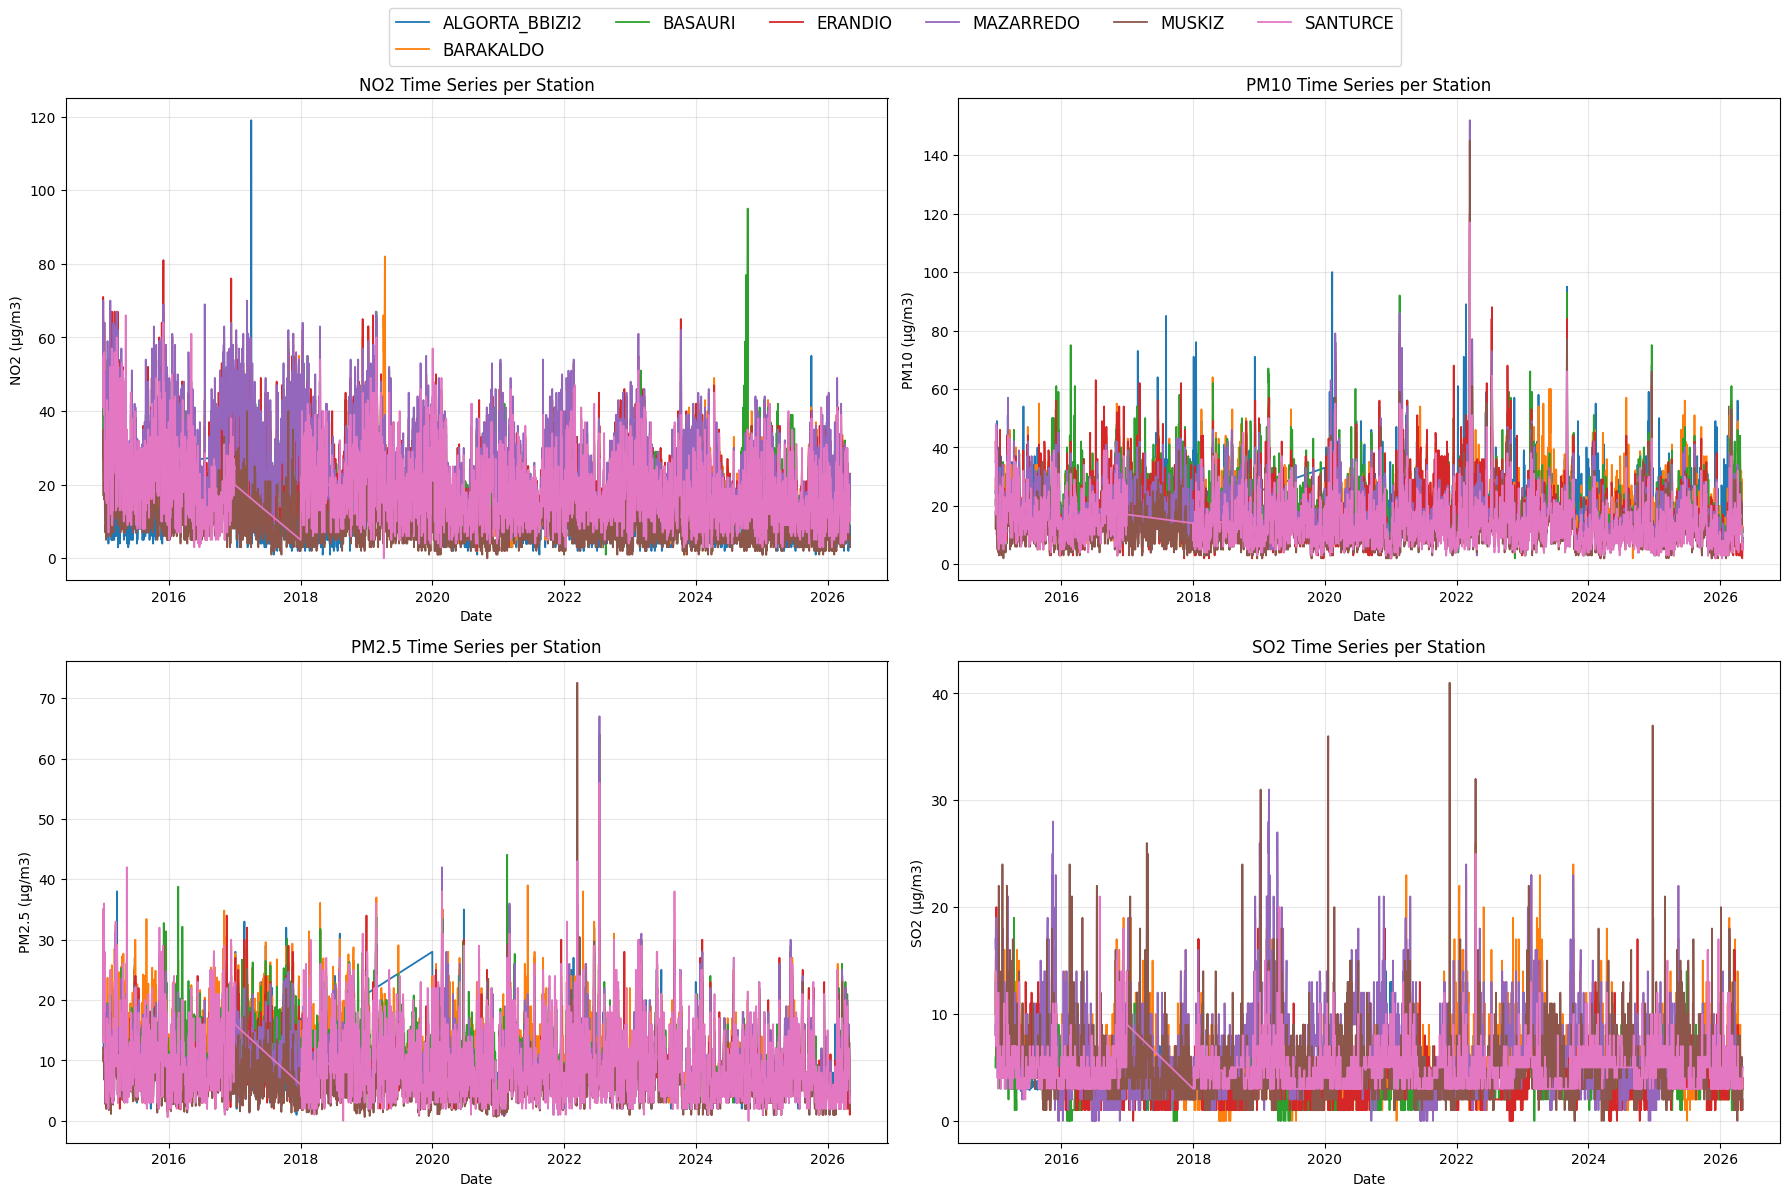

In [6]:
params = ["NO2", "PM10", "PM2.5", "SO2"]
stations = df_final["station"].unique()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()   

for i, param in enumerate(params):
    ax = axes[i]
    
    for st in stations:
        sub = df_final[df_final["station"] == st]
        ax.plot(sub["Date"], sub[param], label=st, linewidth=1.3)
    
    ax.set_title(f"{param} Time Series per Station")
    ax.set_xlabel("Date")
    ax.set_ylabel(f"{param} (µg/m3)")
    ax.grid(True, alpha=0.3)

fig.legend(stations, loc="upper center", ncol=6, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


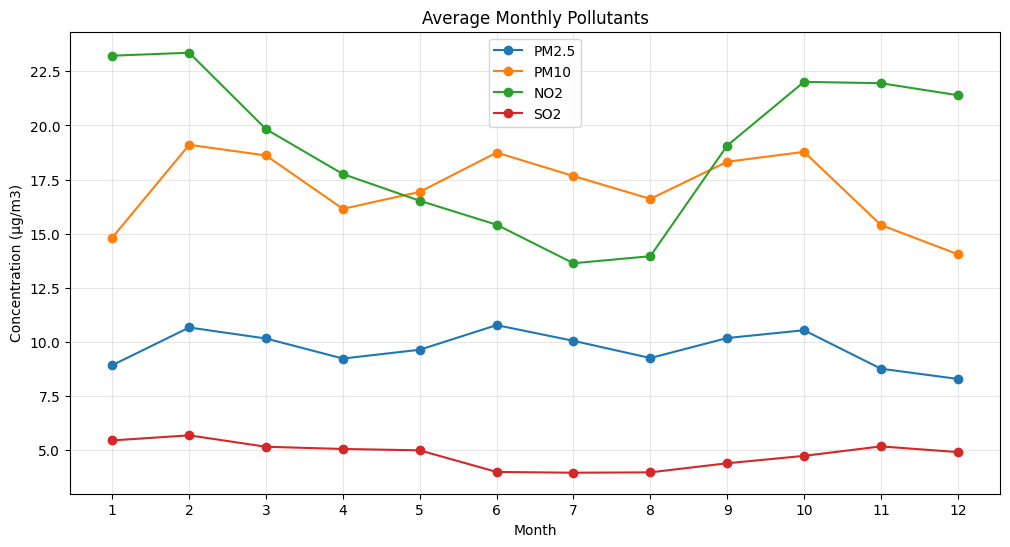

In [7]:
df_final['month'] = df_final['Date'].dt.month

pollutants = ["PM2.5", "PM10", "NO2", "SO2"]

monthly_all = df_final.groupby("month")[pollutants].mean()

plt.figure(figsize=(12, 6))
for col in pollutants:
    plt.plot(monthly_all.index, monthly_all[col], marker="o", label=col)

plt.title("Average Monthly Pollutants")
plt.xlabel("Month")
plt.ylabel("Concentration (µg/m3)") 
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(range(1, 13)) 
plt.show()

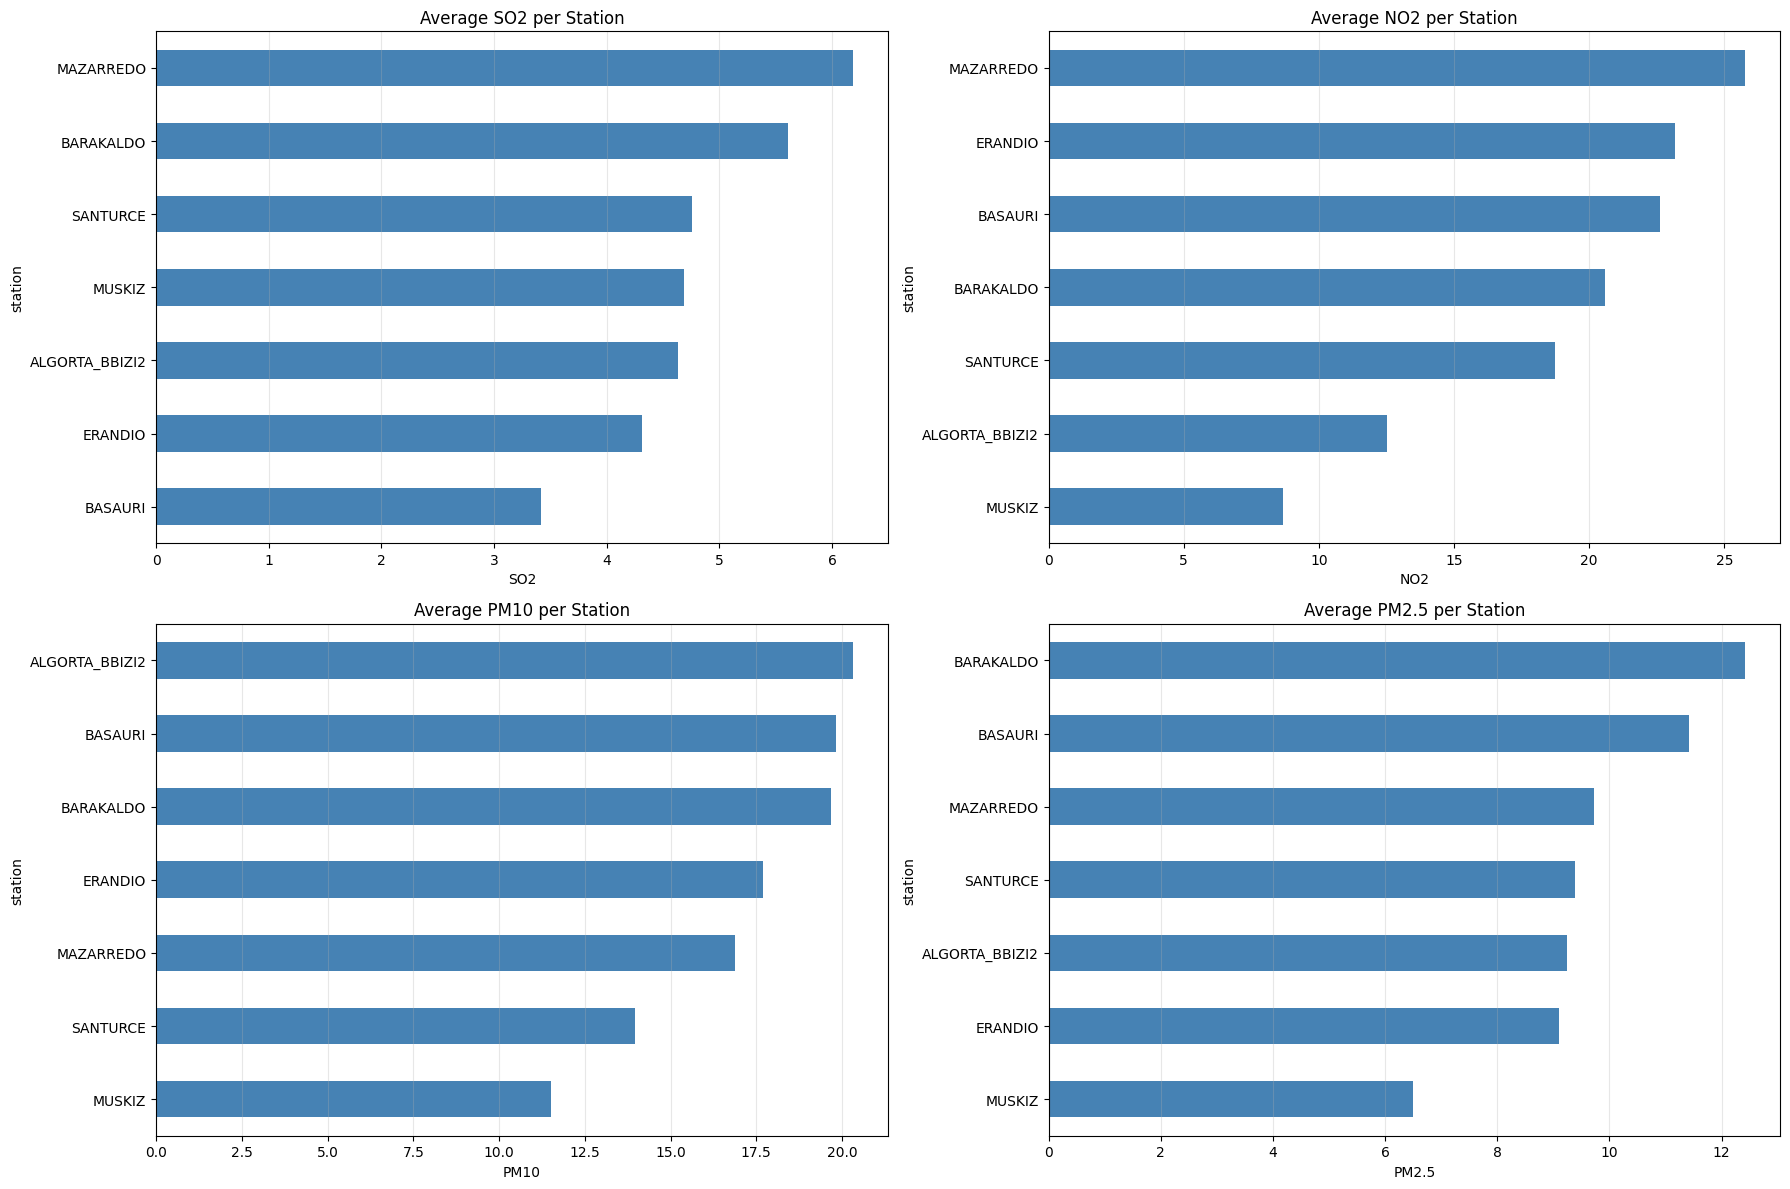

In [8]:
pollutants = [
    "SO2",
    "NO2",
    "PM10",
    "PM2.5"
]

plt.figure(figsize=(18, 12))

for i, col in enumerate(pollutants, 1):
    plt.subplot(2, 2, i)

    station_avg = df_final.groupby("station")[col].mean().sort_values()

    station_avg.plot(kind="barh", color="steelblue")
    plt.title(f"Average {col} per Station")
    plt.xlabel(col)
    plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

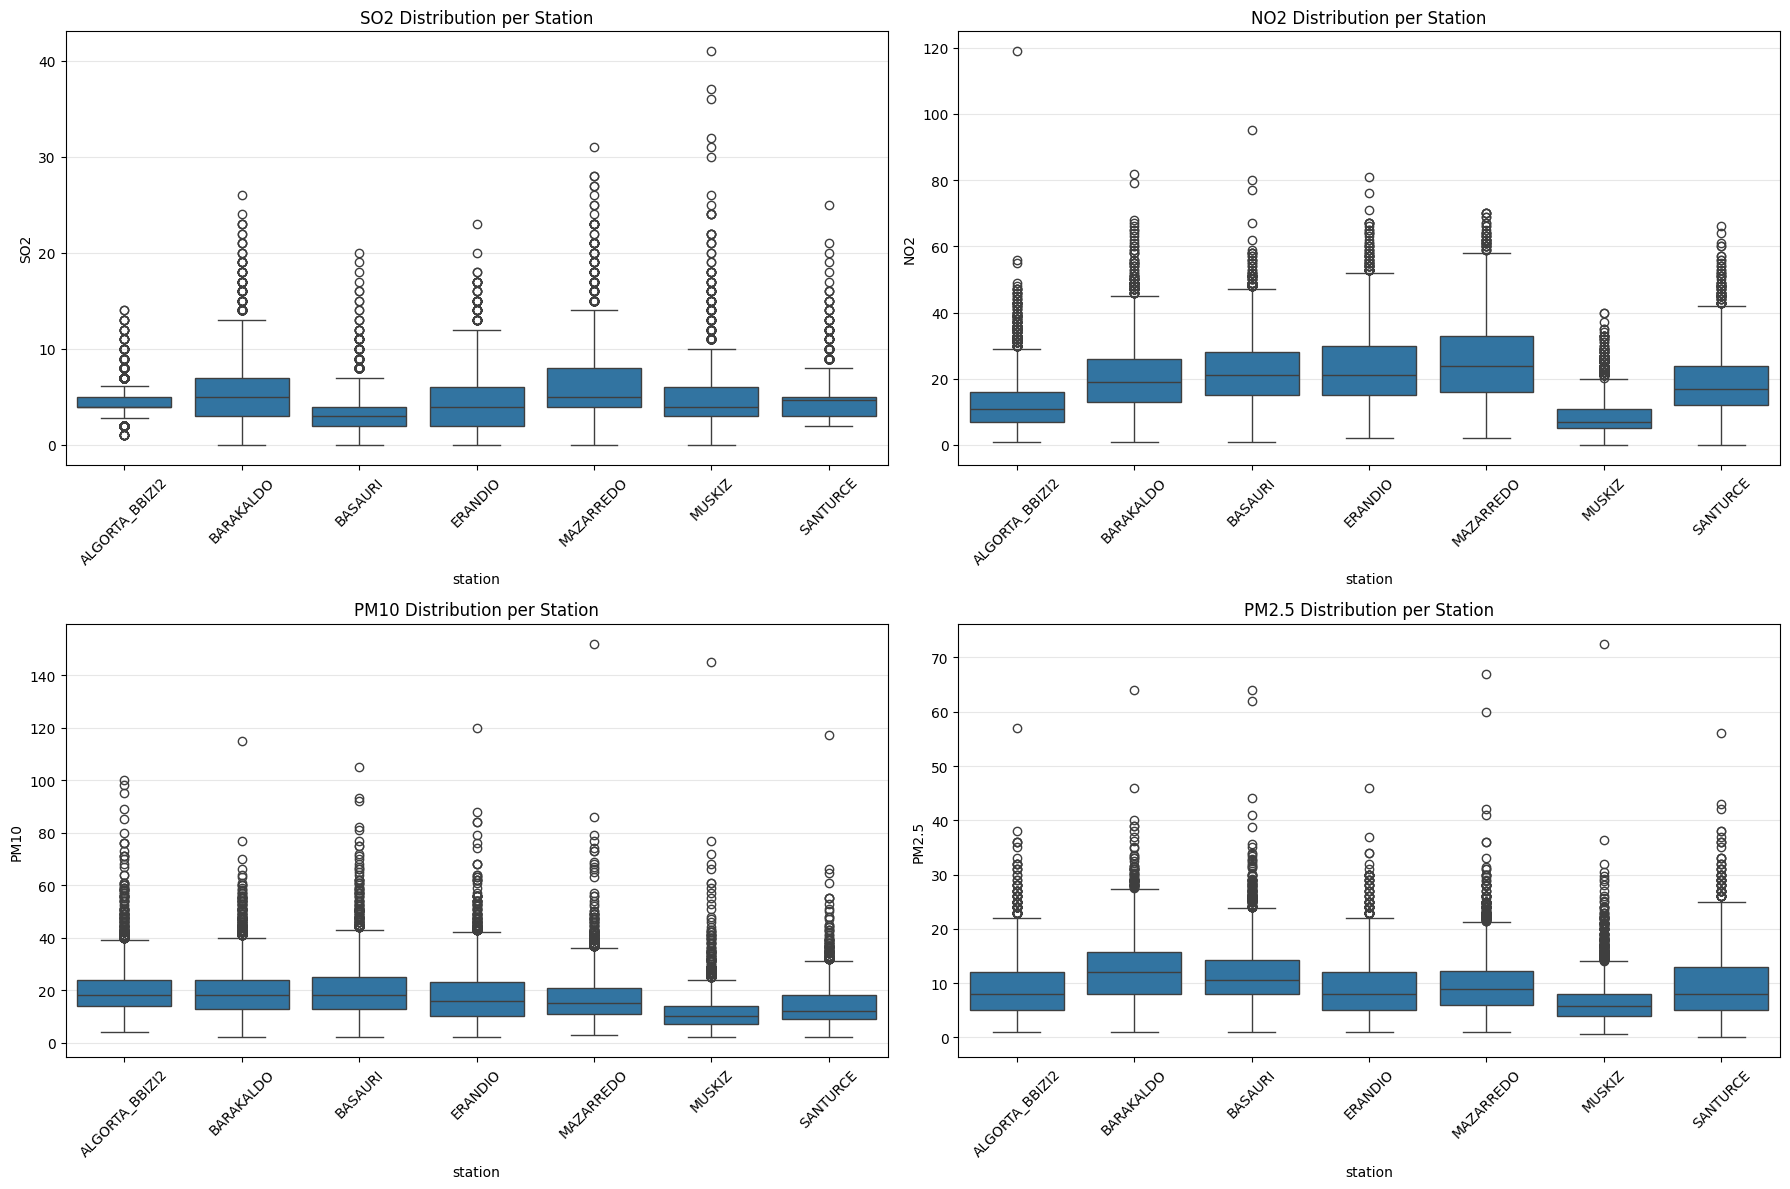

In [9]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(pollutants, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df_final, x="station", y=col)
    plt.title(f"{col} Distribution per Station")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

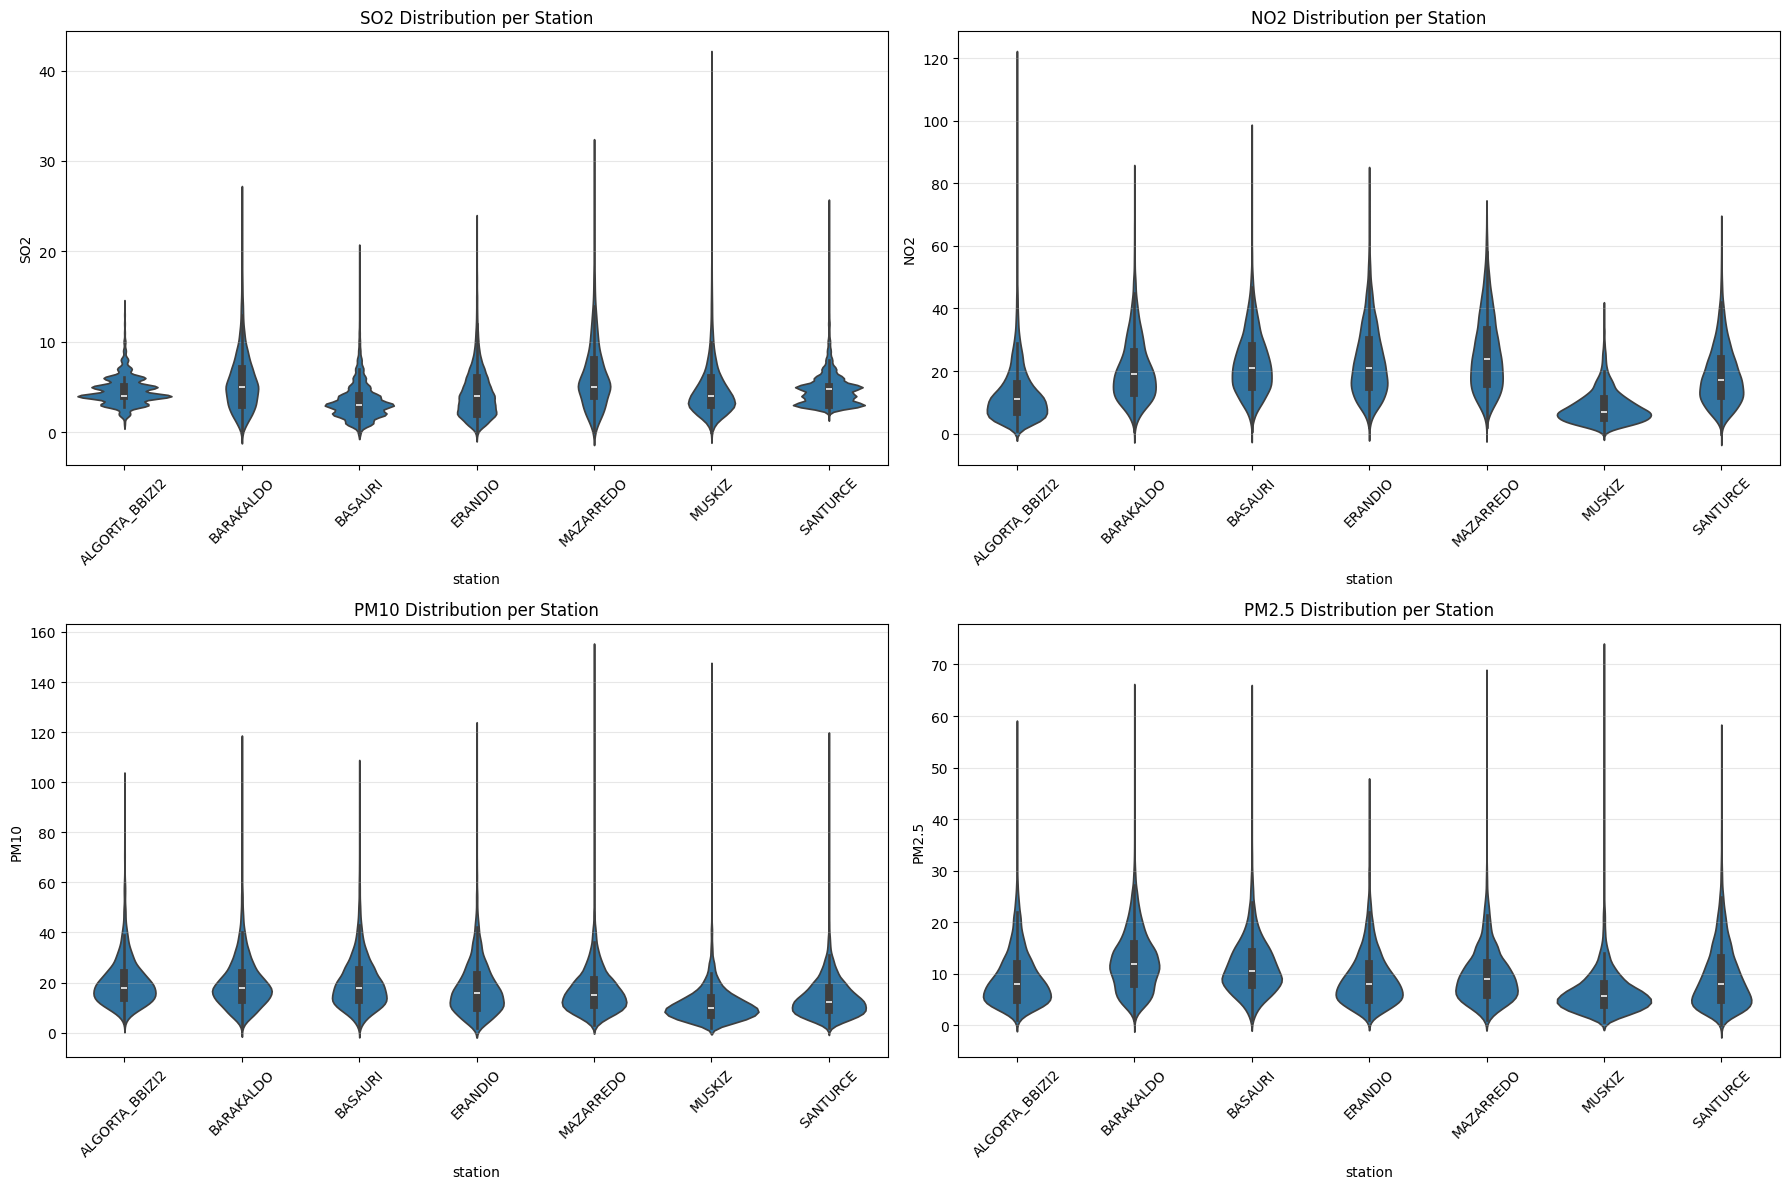

In [10]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(pollutants, 1):
    plt.subplot(2, 2, i)
    sns.violinplot(data=df_final, x="station", y=col)
    plt.title(f"{col} Distribution per Station")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

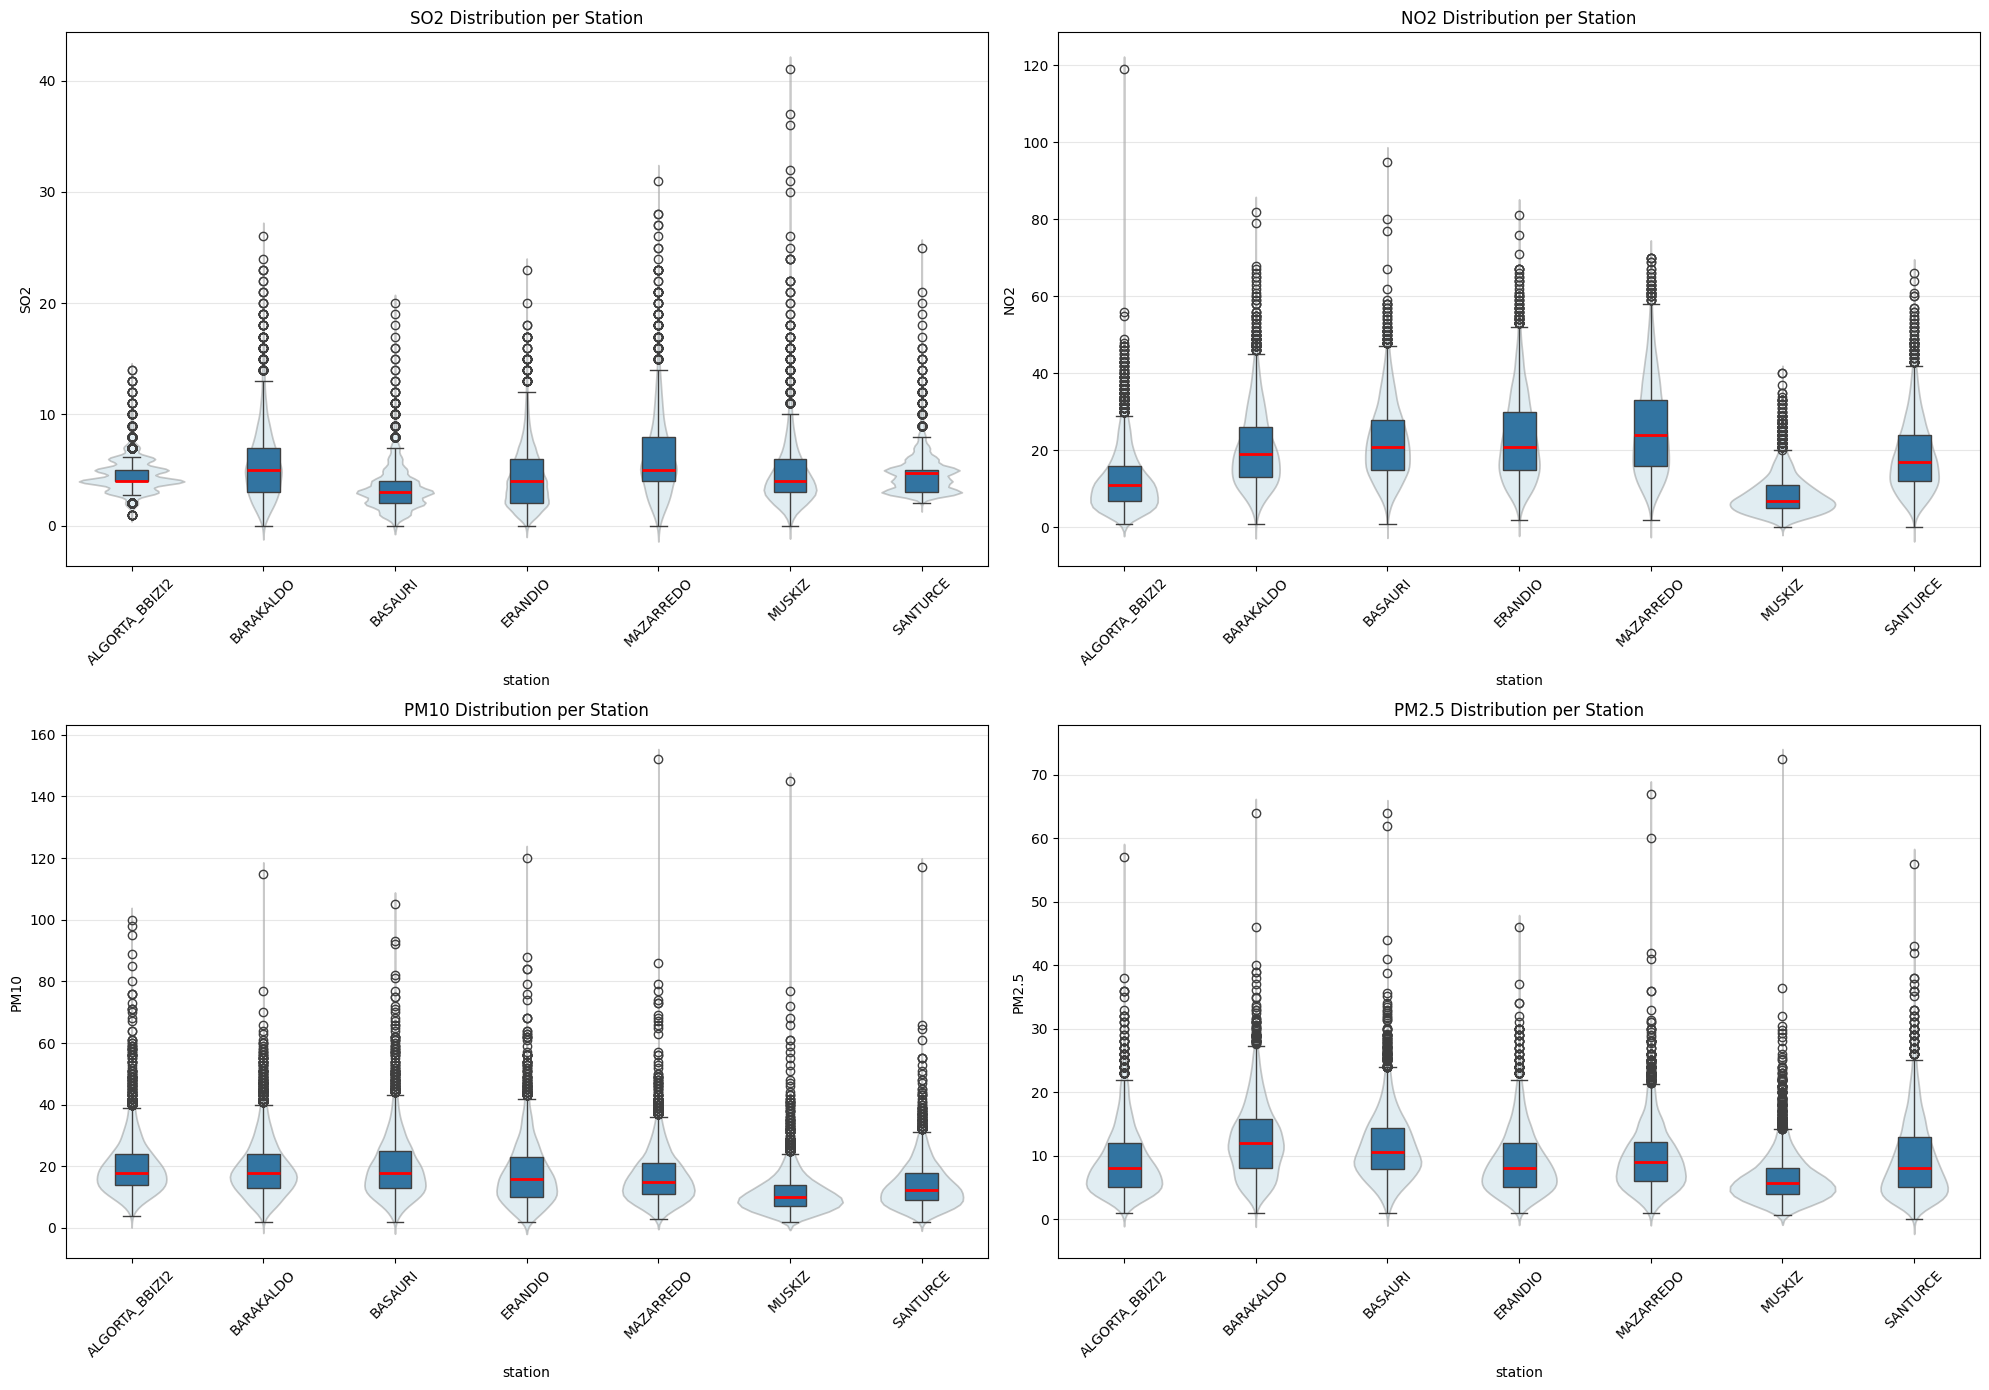

In [ ]:
plt.figure(figsize=(20, 14))

for i, col in enumerate(pollutants, 1):
    plt.subplot(2, 2, i)

    sns.violinplot(
        data=df_final,
        x="station",
        y=col,
        color="lightblue",
        alpha=0.4,      
        inner=None
    )

    sns.boxplot(
        data=df_final,
        x="station",
        y=col,
        width=0.25,    
        boxprops={"zorder": 3},
        whiskerprops={"zorder": 3},
        capprops={"zorder": 3},
        medianprops={"color": "red", "linewidth": 2, "zorder": 4}
    )

    plt.title(f"{col} Distribution per Station")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

PM2.5 — Variabilidad moderada y diferencias claras entre estaciones
Estaciones urbanas muestran valores más altos y dispersión mayor.

Estaciones costeras presentan distribuciones más compactas y niveles bajos.

Los violin plots confirman densidad estable sin colas extremas.

Boxplots indican presencia de outliers naturales pero no excesivos.

Correlación moderada con PM10 en el heatmap.

PM10 — Mayor dispersión y fuerte influencia ambiental
Boxplots revelan amplitud grande entre estaciones, especialmente en zonas urbanas.

Violin plots muestran colas largas y densidad amplia → impacto de viento, obras y polvo sahariano.

Estaciones como BARAKALDO y BASAURI destacan por niveles altos.

Heatmap muestra correlación fuerte con PM2.5.

NO2 — Patrón urbano muy marcado y distribución compacta
Boxplots muestran niveles altos en estaciones céntricas y de tráfico.

Violin plots con forma estrecha → comportamiento estable y predecible.

Muy pocos outliers → emisiones constantes del tráfico.

Heatmap: correlación débil con PM10 y PM2.5, comportamiento independiente.

SO2 — Niveles bajos pero con picos industriales
Boxplots muestran valores bajos en general, pero con outliers frecuentes.

Violin plots indican densidad concentrada con colas pronunciadas en estaciones industriales.

Estaciones como MAZARREDO y MUSKIZ presentan mayor variabilidad.

Heatmap: correlación casi nula con otros contaminantes → fuente distinta (industrial/portuaria).

🧠 Resumen Final

PM2.5: estable, urbano, tendencia a la baja.

PM10: variable, sensible a factores ambientales, correlación fuerte con PM2.5.

NO2: claramente urbano, muy estable, pocos outliers.

SO2: bajo pero irregular, asociado a actividad industrial.

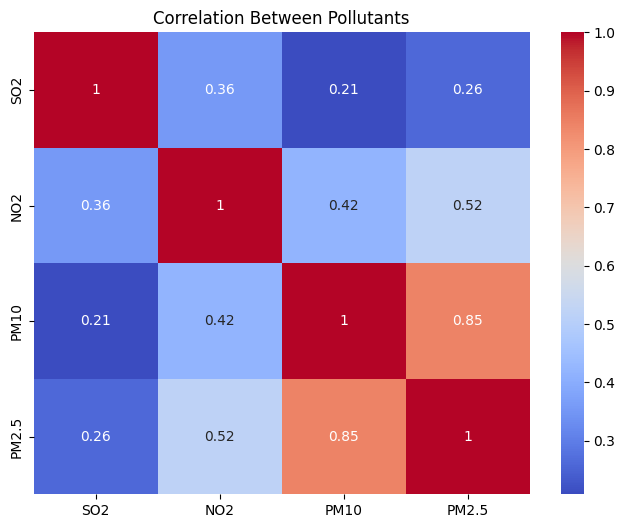

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df_final[pollutants].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Pollutants")
plt.show()

PM2.5 y PM10 → correlación alta y positiva. Comparten fuentes (tráfico, polvo, obras).

NO2 → correlación débil con partículas. Es un contaminante puramente urbano.

SO2 → correlación casi nula con todos. Tiene origen industrial/portuario

In [15]:
corr_station = df_final.groupby("station")[pollutants].corr()
corr_station

SO2       NO2      PM10     PM2.5
station                                                     
ALGORTA_BBIZI2 SO2    1.000000  0.325944  0.061028  0.071332
               NO2    0.325944  1.000000  0.227396  0.441599
               PM10   0.061028  0.227396  1.000000  0.694184
               PM2.5  0.071332  0.441599  0.694184  1.000000
BARAKALDO      SO2    1.000000  0.450833  0.273887  0.271833
               NO2    0.450833  1.000000  0.361198  0.508009
               PM10   0.273887  0.361198  1.000000  0.783647
               PM2.5  0.271833  0.508009  0.783647  1.000000
BASAURI        SO2    1.000000  0.358425  0.282056  0.271948
               NO2    0.358425  1.000000  0.457984  0.517132
               PM10   0.282056  0.457984  1.000000  0.942034
               PM2.5  0.271948  0.517132  0.942034  1.000000
ERANDIO        SO2    1.000000  0.455979  0.285193  0.379921
               NO2    0.455979  1.000000  0.498516  0.574974
               PM10   0.285193  0.498516  1.000000  0.865306
               PM2.5  0.379921  0.574974  0.865306  1.000000
MAZARREDO      SO2    1.000000  0.462914  0.339960  0.384585
               NO2    0.462914  1.000000  0.410782  0.440132
               PM10   0.339960  0.410782  1.000000  0.927763
               PM2.5  0.384585  0.440132  0.927763  1.000000
MUSKIZ         SO2    1.000000  0.410279  0.190364  0.269411
               NO2    0.410279  1.000000  0.401765  0.532138
               PM10   0.190364  0.401765  1.000000  0.960712
               PM2.5  0.269411  0.532138  0.960712  1.000000
SANTURCE       SO2    1.000000  0.319694  0.177880  0.271386
               NO2    0.319694  1.000000  0.556641  0.601889
               PM10   0.177880  0.556641  1.000000  0.882110
               PM2.5  0.271386  0.601889  0.882110  1.000000

C:\Users\Dell\AppData\Local\Temp\ipykernel_4424\793086293.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


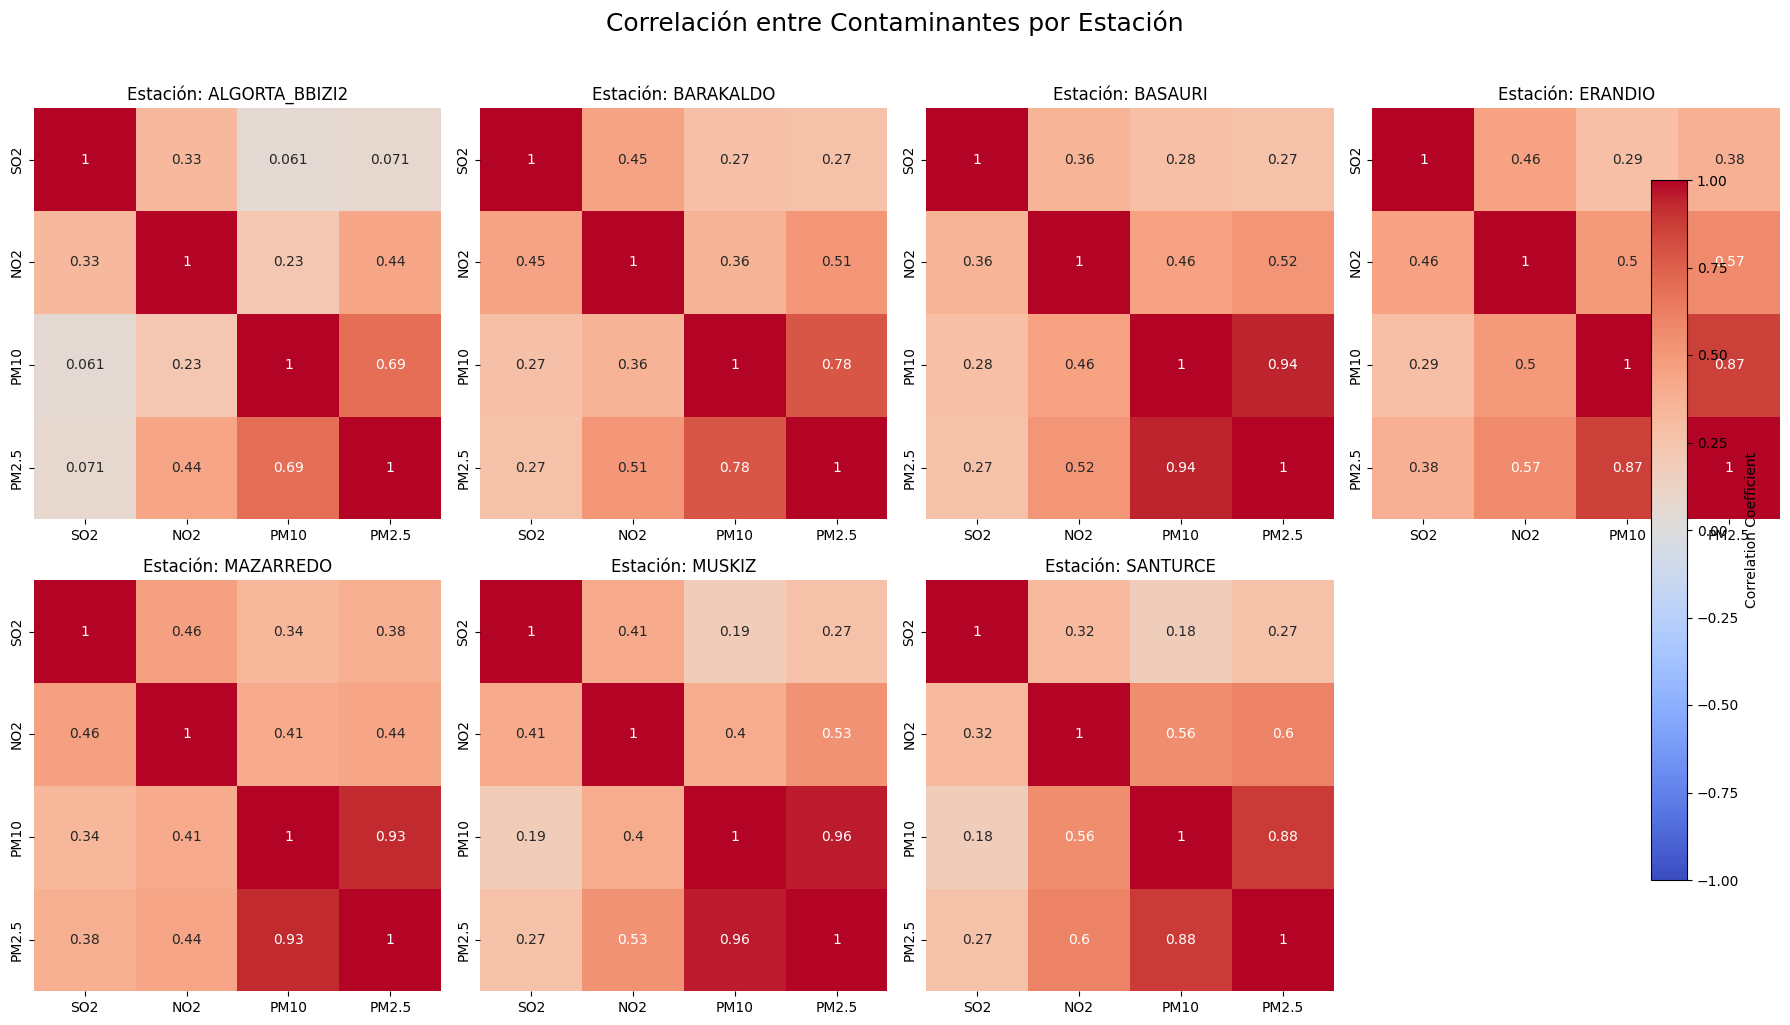

In [17]:
import math

stations = df_final["station"].unique()

# grid size
n_cols = 4
n_rows = math.ceil(len(stations) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, st in enumerate(stations):

    sub = df_final[df_final["station"] == st][pollutants]
    corr = sub.corr()

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        ax=axes[i],
        cbar=False
    )

    axes[i].set_title(f"Estación: {st}", fontsize=12)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.subplots_adjust(right=0.9)



sm = plt.cm.ScalarMappable(cmap="coolwarm")
sm.set_clim(-1, 1)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(sm, cax=cbar_ax, label="Correlation Coefficient")

plt.suptitle(
    "Correlación entre Contaminantes por Estación",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

🟦 ALGORTA_BBIZI2

— Correlaciones moderadas y ambiente costero PM2.5–PM10: 0.69 → relación moderada, típica de zonas con viento.

NO2–PM2.5: 0.44 → influencia urbana ligera.

SO2 casi independiente (0.08–0.34) → sin actividad industrial fuerte.

Conclusión: estación costera con dispersión natural alta.

🟥 BARAKALDO

— Correlaciones urbanas fuertes PM2.5–PM10: 0.88 → relación muy fuerte (zona urbana densa).

NO2 correlaciona con ambos (0.37–0.42) → tráfico dominante.

SO2 moderado (0.27–0.28) → posible mezcla urbana-industrial.

Conclusión: comportamiento urbano clásico con fuentes múltiples.

🟧 BASAURI

— La correlación más alta entre partículas PM2.5–PM10: 0.95 → casi perfecta.

NO2 correlación media (0.45–0.48) → tráfico importante.

SO2 débil (0.25–0.28) → poca influencia industrial.

Conclusión: estación urbana donde PM2.5 y PM10 se mueven juntos.

🟩 ERANDIO

— Influencia fuerte del tráfico PM2.5–PM10: 0.86 → relación sólida.

NO2–PM2.5: 0.57 → tráfico muy influyente.

NO2–PM10: 0.49 → relación más fuerte que en otras estaciones.

SO2 moderado (0.28–0.38) → mezcla urbana-industrial ligera.

Conclusión: estación con fuerte componente de tráfico.

🟪 MAZARREDO

— Zona céntrica con mezcla urbana-portuaria PM2.5–PM10: 0.92 → relación muy alta.

NO2 correlación media (0.41–0.44) → tráfico urbano.

SO2 correlación media (0.34–0.38) → influencia portuaria/industrial.

Conclusión: estación híbrida (urbana + puerto).

🟫 MUSKIZ

— Dominio industrial claro PM2.5–PM10: 0.95 → partículas muy alineadas.

NO2 correlación media (0.40–0.54) → tráfico secundario.

SO2 correlación baja (0.19–0.27) → SO2 independiente por origen industrial.

Conclusión: estación industrial donde SO2 tiene dinámica propia.

🟨 SANTURCE

— Estación costera con buena dispersión PM2.5–PM10: 0.88 → relación fuerte pero estable.

NO2 correlación media (0.55–0.60) → tráfico moderado.

SO2 muy bajo (0.17–0.27) → sin impacto industrial fuerte.

Conclusión: estación costera con buena ventilación y patrones limpios.

# Conclusión Global (Resumen Profesional)

PM2.5–PM10 → correlación muy fuerte en TODAS las estaciones Más alta en BASAURI, MUSKIZ, MAZARREDO
Más baja en ALGORTA (efecto del viento)

NO2 → comportamiento urbano Correlación más fuerte en ERANDIO y SANTURCE
Más débil en zonas costeras como ALGORTA

SO2 → contaminante independiente Correlación baja en todas las estaciones
Más relevante en MAZARREDO y MUSKIZ (zonas industriales/portuarias)

La correlación depende del tipo de estación Urbana: correlaciones altas y estables
Costera: correlaciones más bajas

Industrial: SO2 rompe patrones típicos

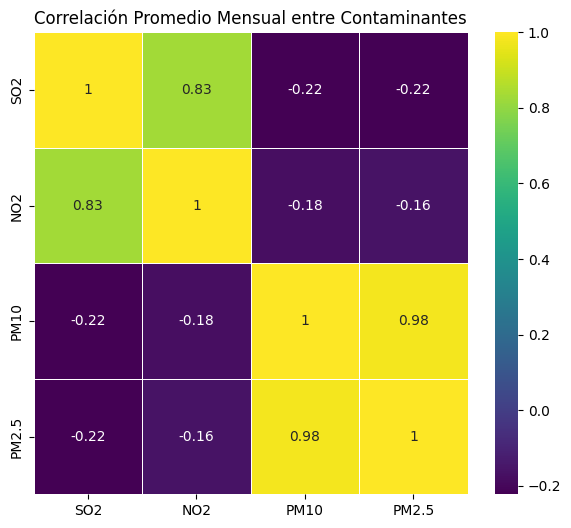

In [26]:
df_final["month"] = df_final["Date"].dt.month

monthly_corr = df_final.groupby("month")[pollutants].mean().corr()

plt.figure(figsize=(7,6))
sns.heatmap(monthly_corr, annot=True, cmap="viridis", linewidths=0.5)
plt.title("Correlación Promedio Mensual entre Contaminantes")
plt.show()

El análisis de correlación mensual reveló dos grupos claros de contaminantes. Las partículas PM2.5 y PM10 mostraron una correlación positiva muy fuerte, lo que sugiere fuentes de emisión comunes y un comportamiento atmosférico similar. Asimismo, el NO2 y el SO2 mostraron una fuerte correlación positiva, probablemente asociada con actividades relacionadas con la combustión y emisiones industriales. Las débiles correlaciones negativas entre la materia particulada y los contaminantes gaseosos indican dinámicas estacionales y patrones de emisión diferentes.

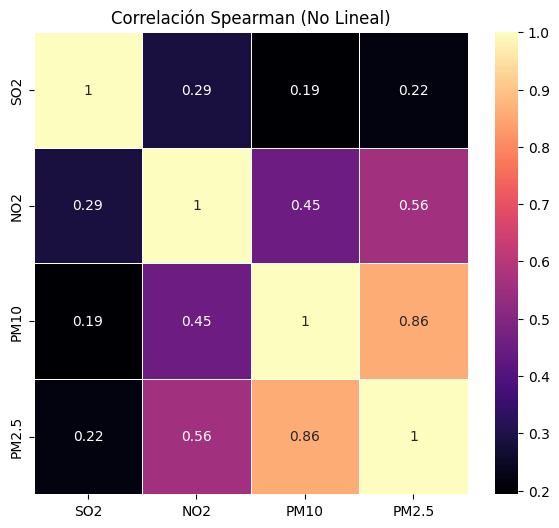

In [27]:
plt.figure(figsize=(7,6))
sns.heatmap(df_final[pollutants].corr(method="spearman"), annot=True, cmap="magma", linewidths=0.5)
plt.title("Correlación Spearman (No Lineal)")
plt.show()

Spearman confirma que PM2.5 y PM10 suben y bajan juntos, incluso cuando la relación no es lineal.

NO2 mantiene independencia estructural.

SO2 sigue sin relación → fuente distinta.

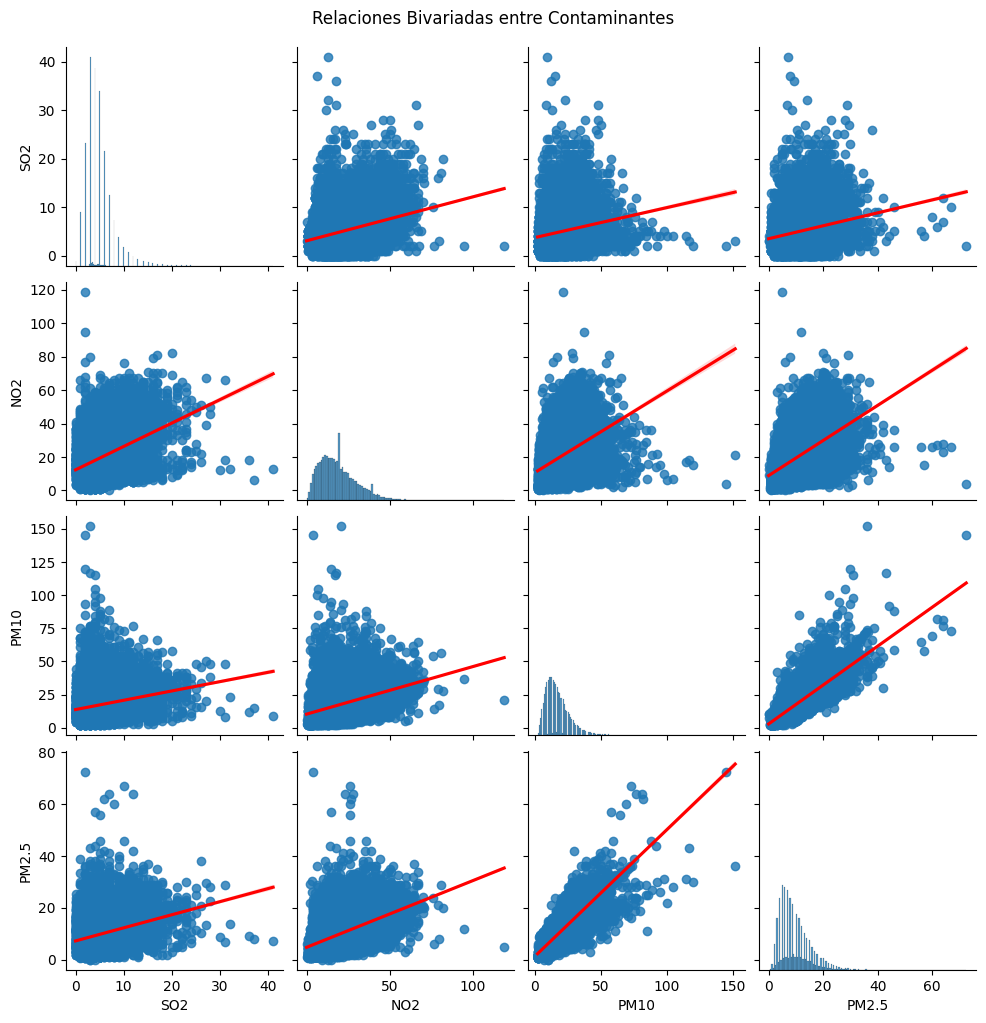

In [28]:
sns.pairplot(df_final[pollutants], kind="reg", plot_kws={"line_kws": {"color": "red"}})
plt.suptitle("Relaciones Bivariadas entre Contaminantes", y=1.02)
plt.show()

PM2.5 ↔ PM10 — Relación más fuerte y estable
La línea roja de regresión tiene pendiente positiva fuerte.

PM2.5 y PM10 comparten fuentes (tráfico, polvo, obras) y tienen correlación estructural.

PM2.5 ↔ NO2 — Relación moderada
La nube de puntos es más dispersa.

La línea roja tiene pendiente positiva pero débil.

NO2 depende del tráfico, mientras que PM2.5 tiene fuentes mixtas.

Relación urbana, pero no tan fuerte como entre partículas.

PM10 ↔ NO2 — Relación débil
Los puntos están muy dispersos.

PM10 está influido por viento, polvo sahariano y obras → NO2 solo por tráfico.

NO2 no es un buen predictor de PM10.

NO2 ↔ SO2 — Relación débil pero visible
Ligera pendiente positiva.

El SO2 presenta picos industriales que el NO2 no comparte.

Relación mixta: tráfico + industria.

PM2.5 ↔ SO2 — Relación débil
Pendiente muy baja.

El SO2 proviene de fuentes industriales, el PM2.5 de fuentes urbanas y naturales.

El SO2 se comporta de forma independiente del PM2.5.

PM10 ↔ SO2 — Casi sin relación.
Línea de regresión casi plana.

El PM10 está influenciado por el viento y el polvo, el SO2 por la industria.

Dinámicas totalmente diferentes.

PM2.5 y PM10 → relación más fuerte y estable.
NO2 → correlación moderada con partículas، pero مستقل en بسیاری de casos.
SO2 → contaminante industrial con comportamiento independiente.
Las relaciones no lineales también confirman los mismos patrones (Spearman).

Los histogramas diagonales muestran que cada contaminante tiene distribución propia.

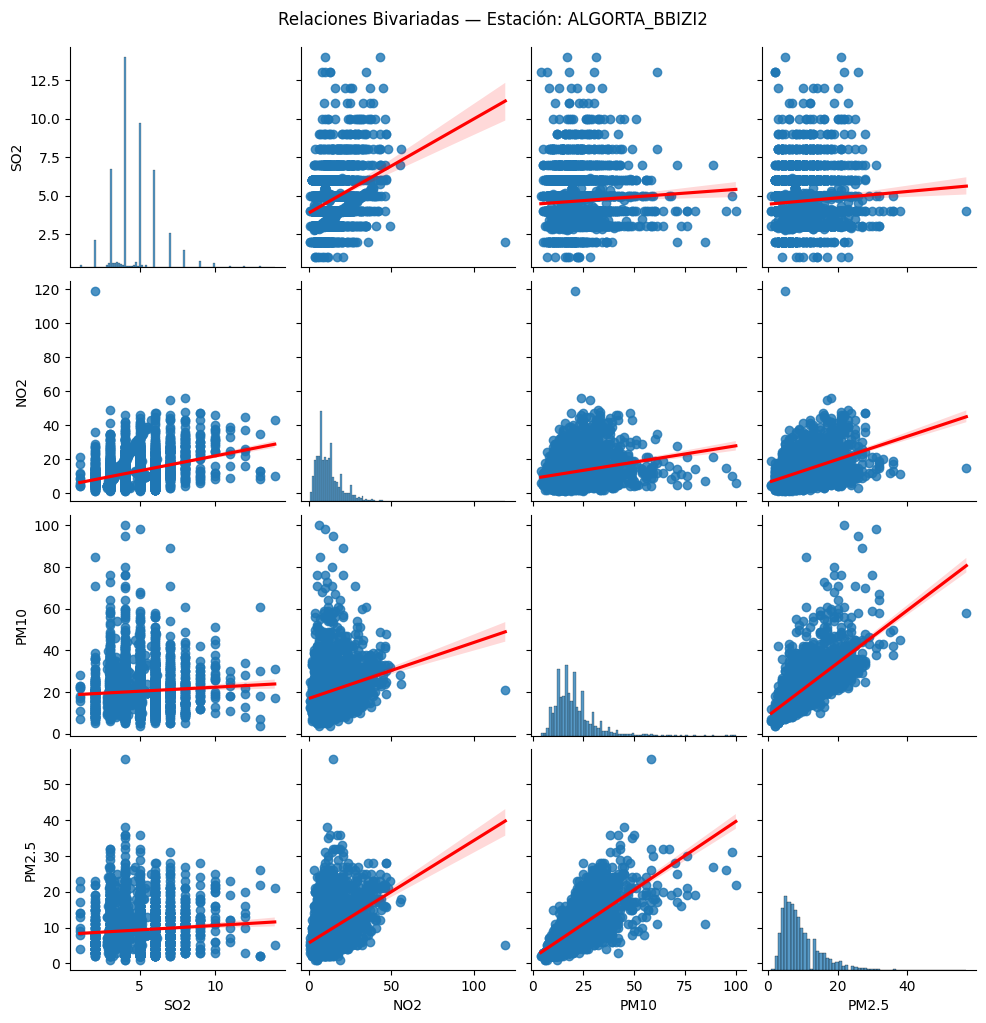

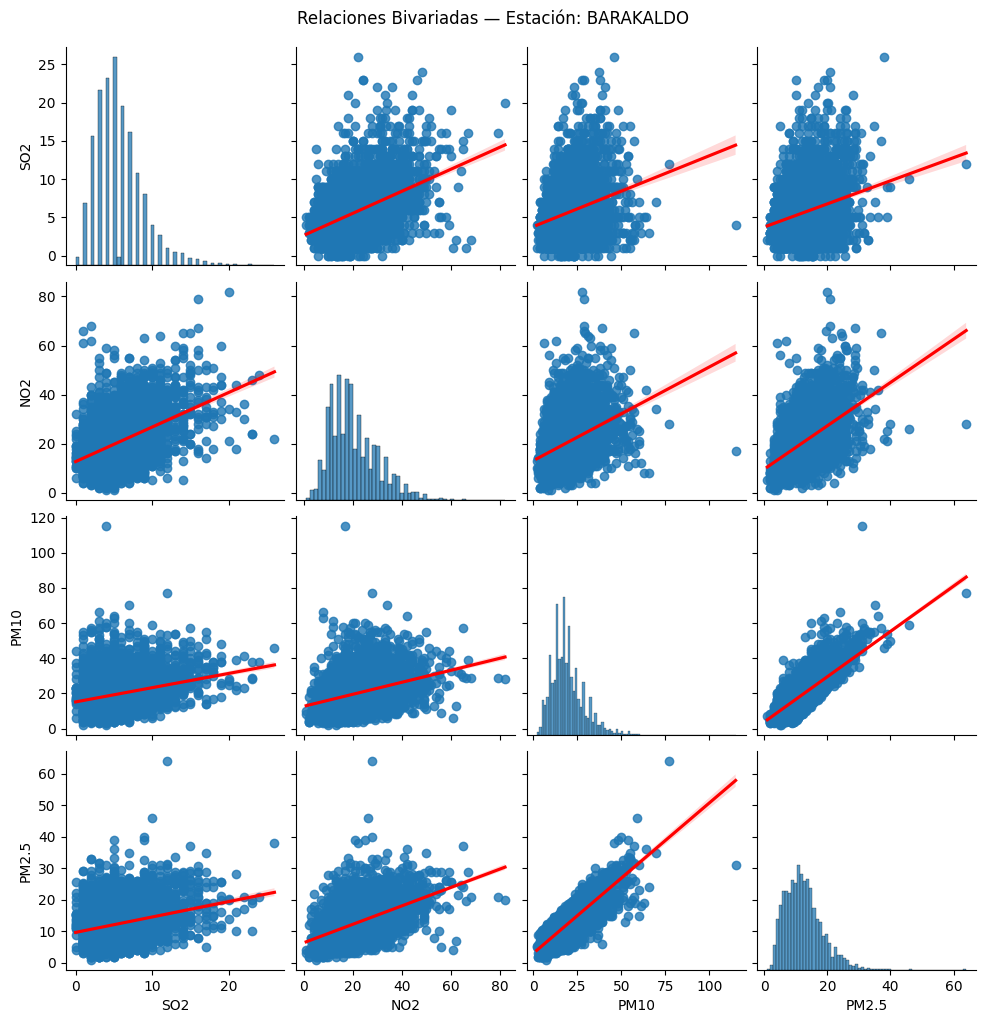

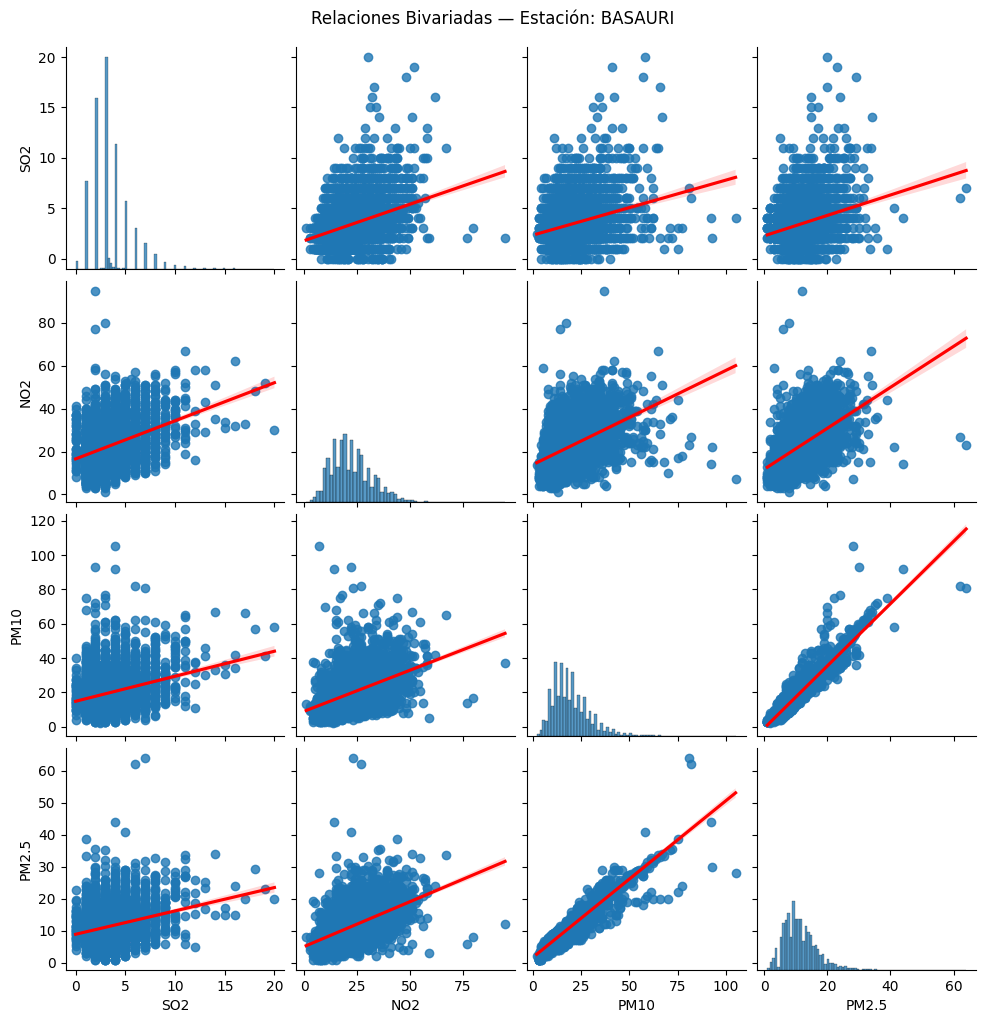

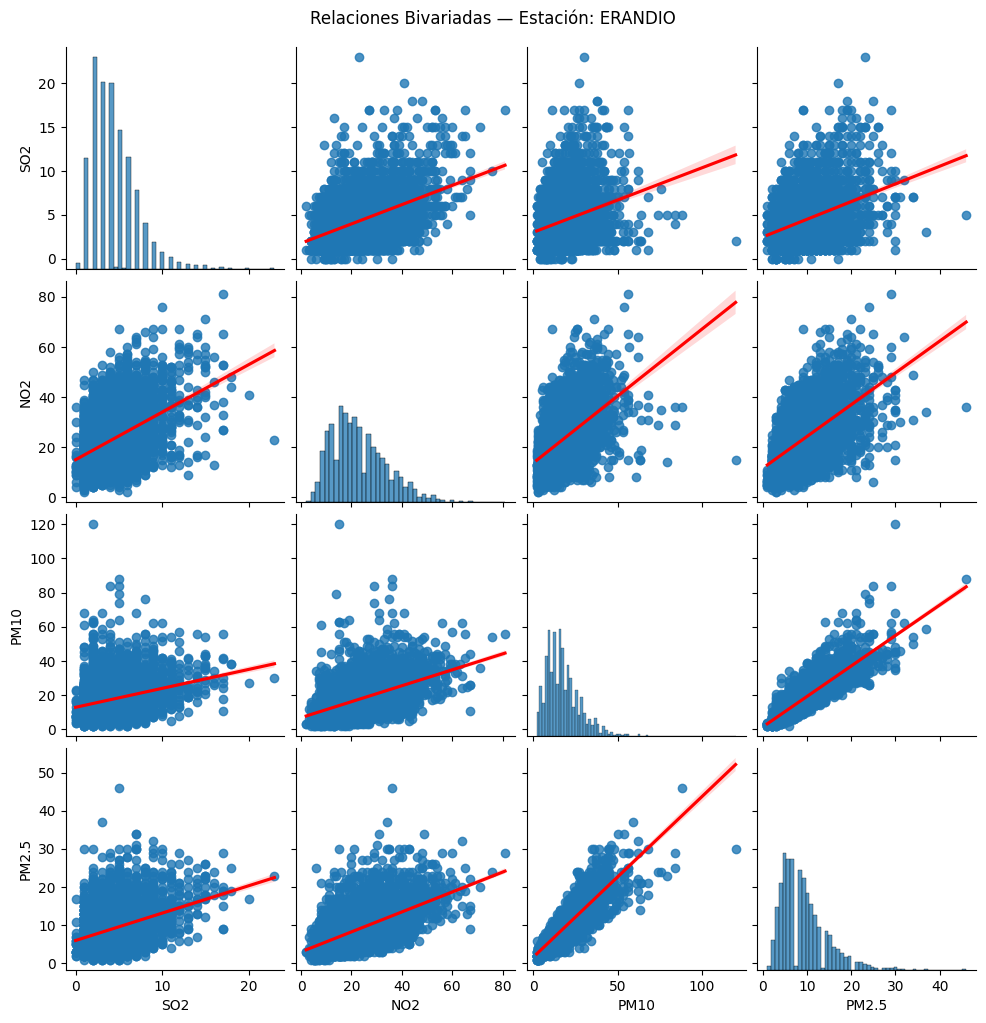

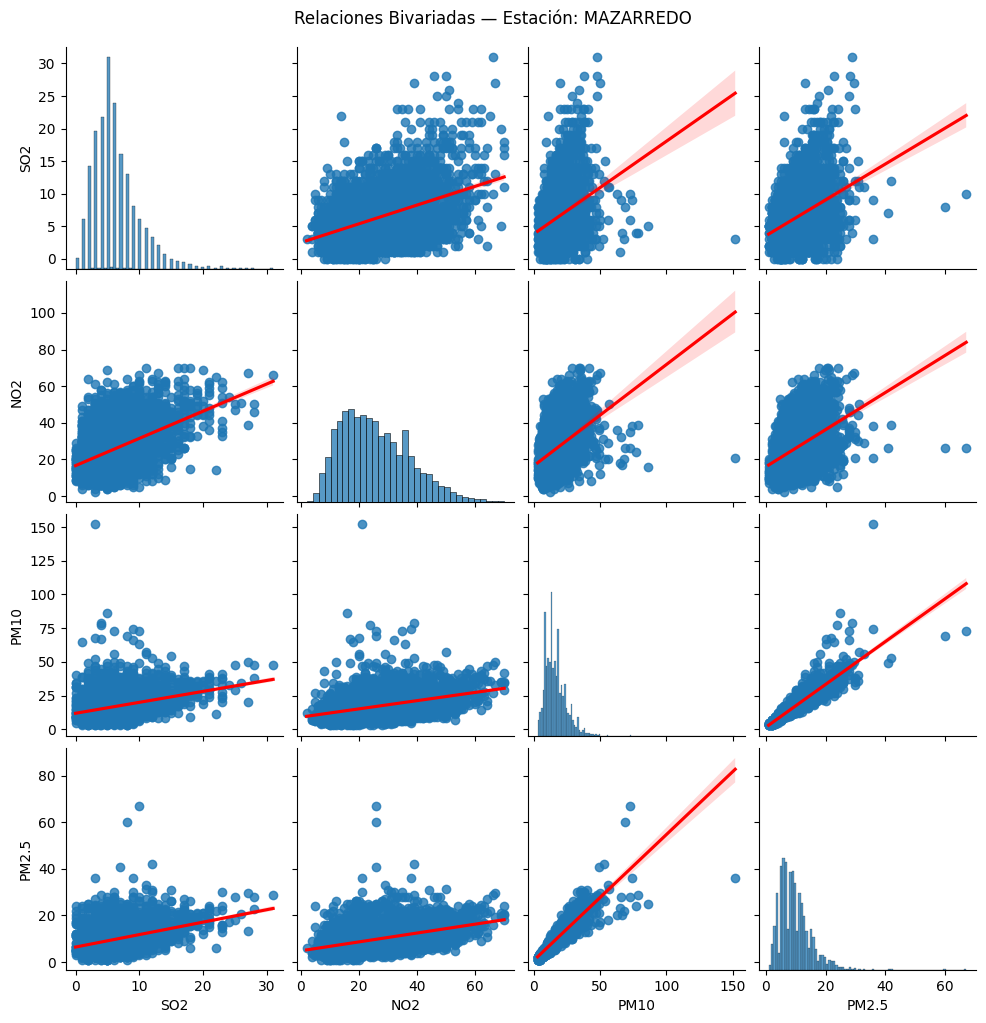

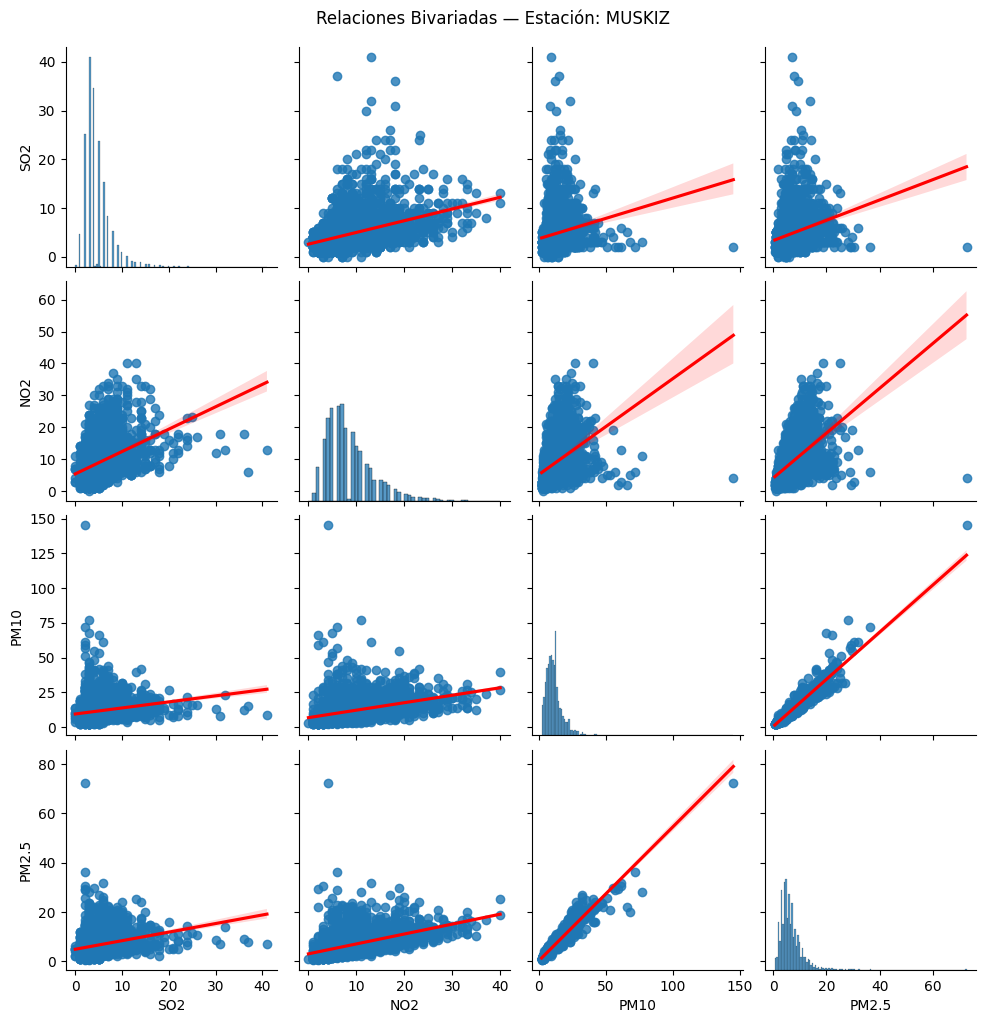

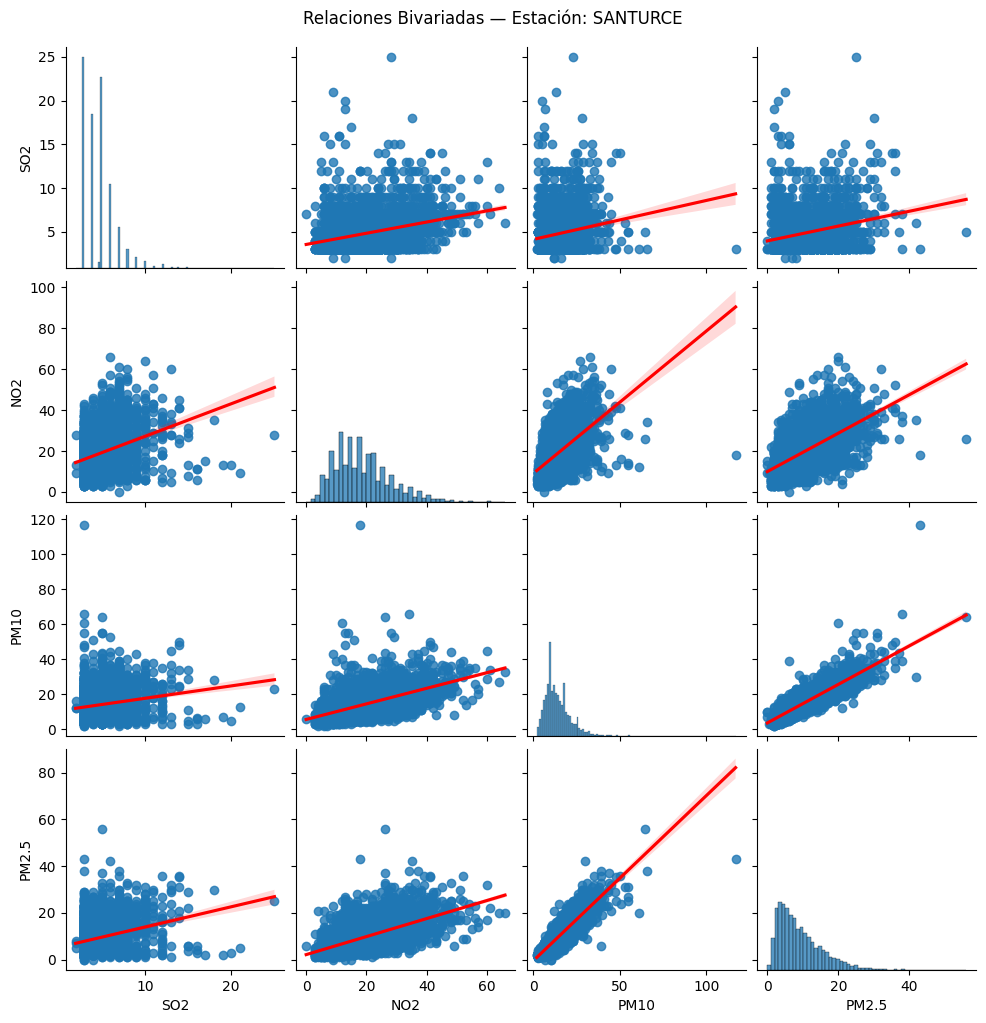

In [25]:
stations = df_final["station"].unique()

for st in stations:
    sub = df_final[df_final["station"] == st][pollutants]

    sns.pairplot(sub, kind="reg", plot_kws={"line_kws": {"color": "red"}})
    plt.suptitle(f"Relaciones Bivariadas — Estación: {st}", y=1.02)
    plt.show()

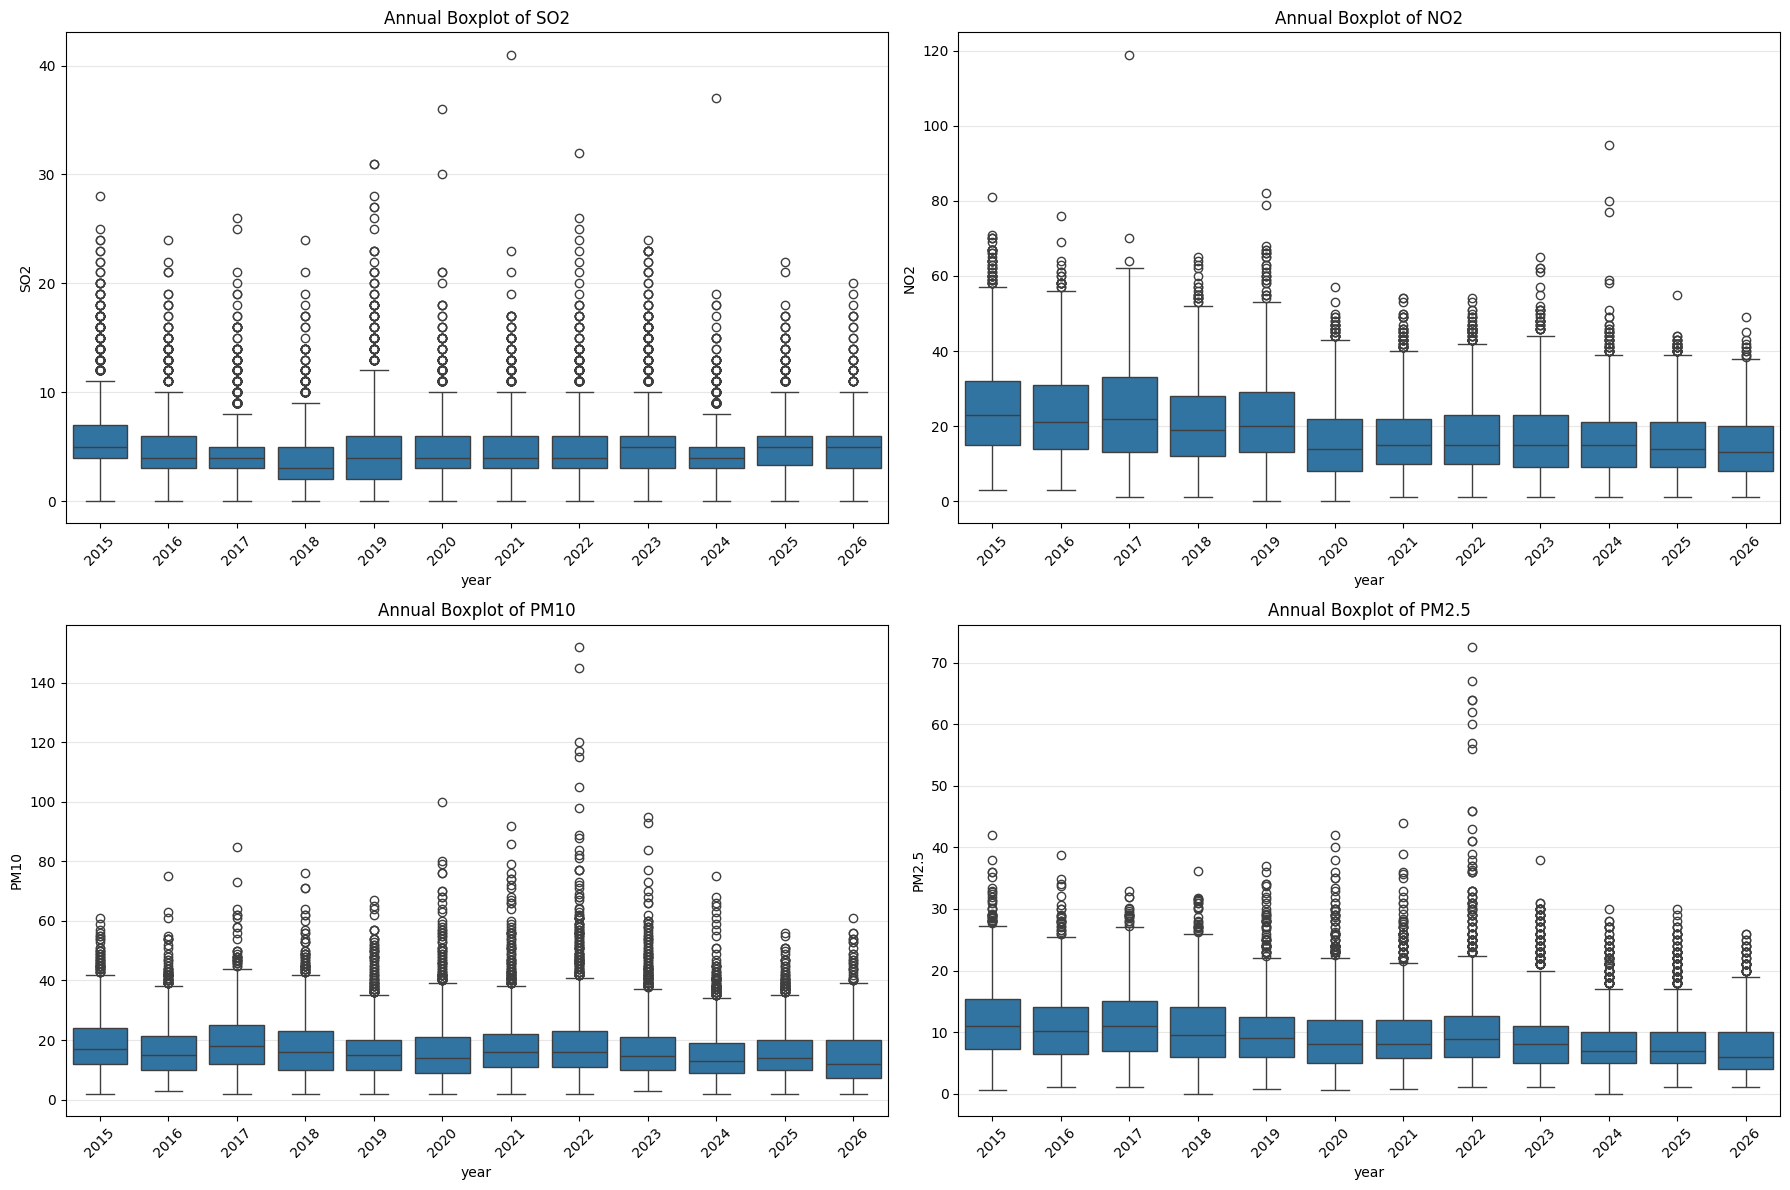

In [29]:
df_final["year"] = df_final["Date"].dt.year

plt.figure(figsize=(18, 12))

for i, col in enumerate(pollutants, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df_final, x="year", y=col)
    plt.title(f"Annual Boxplot of {col}")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

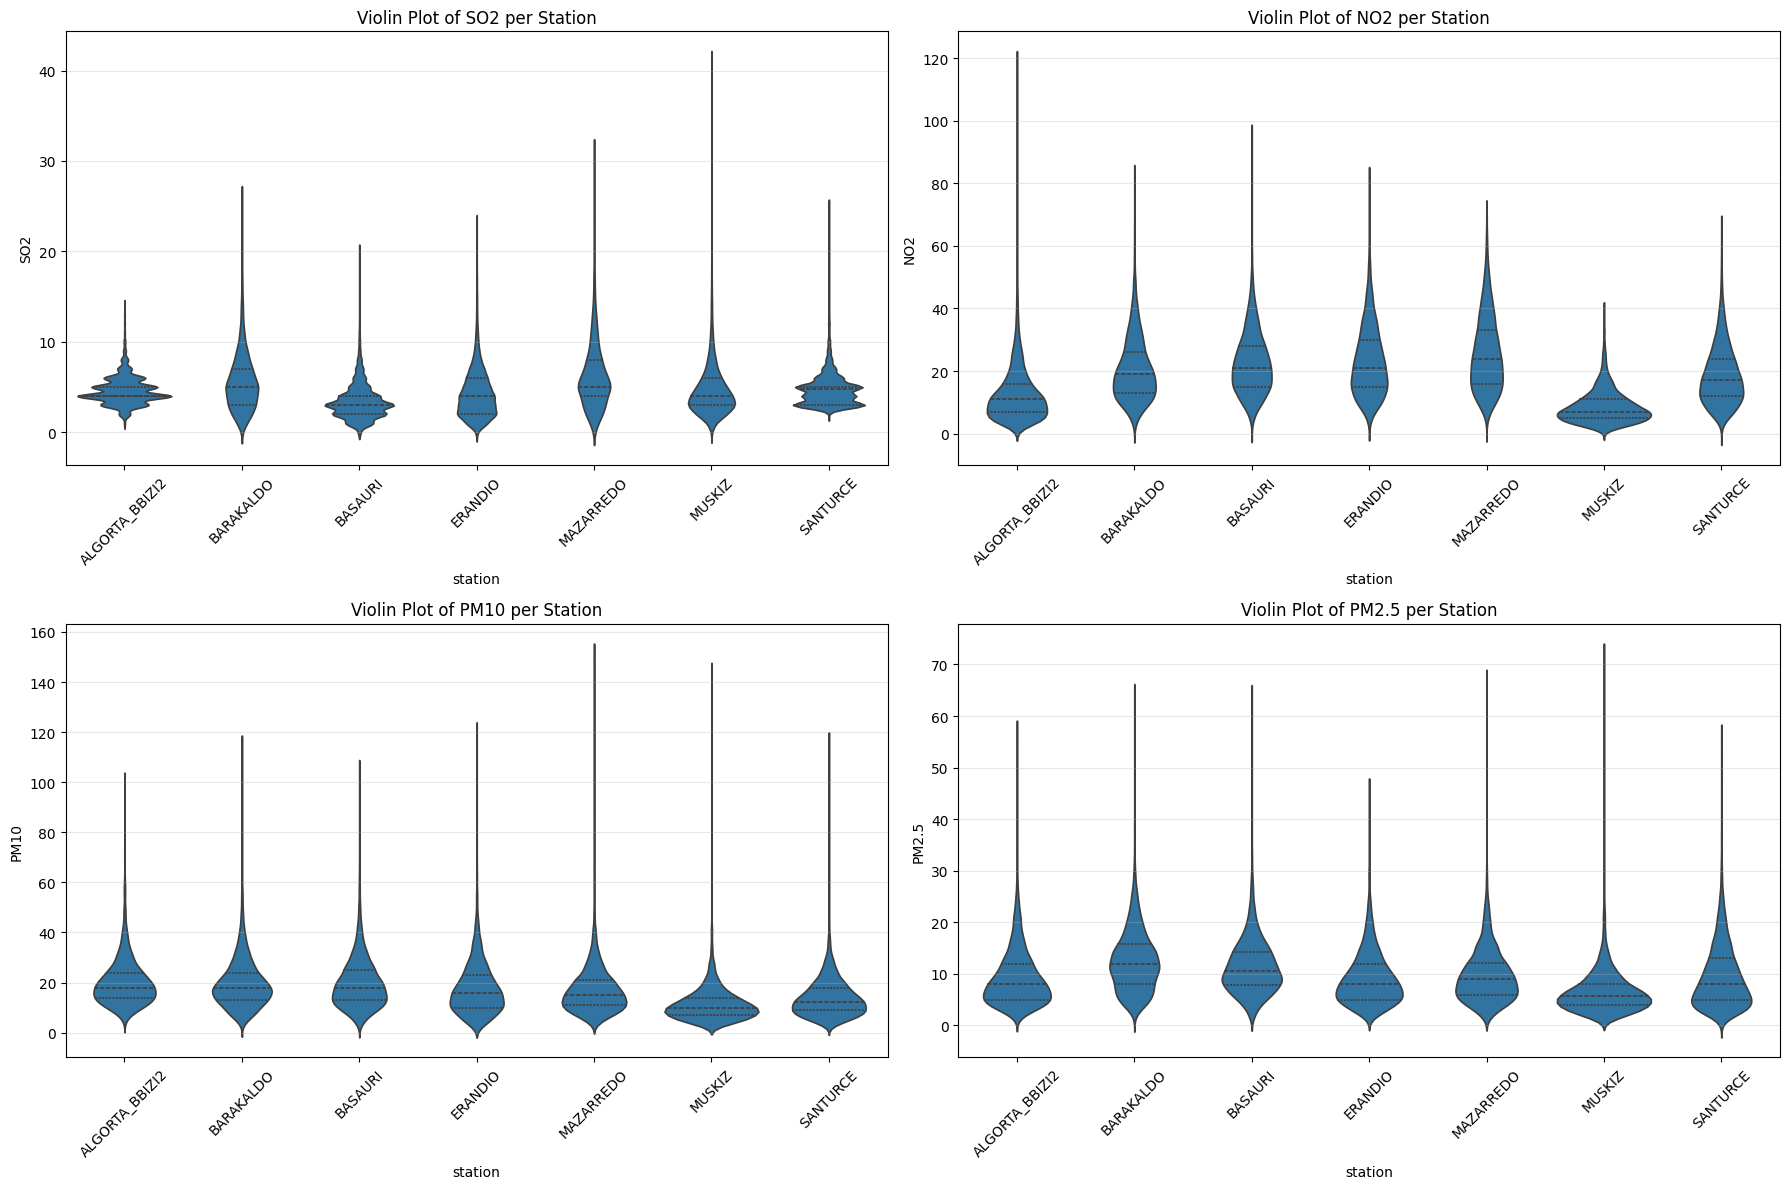

In [30]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(pollutants, 1):
    plt.subplot(2, 2, i)
    sns.violinplot(data=df_final, x="station", y=col, inner="quartile")
    plt.title(f"Violin Plot of {col} per Station")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

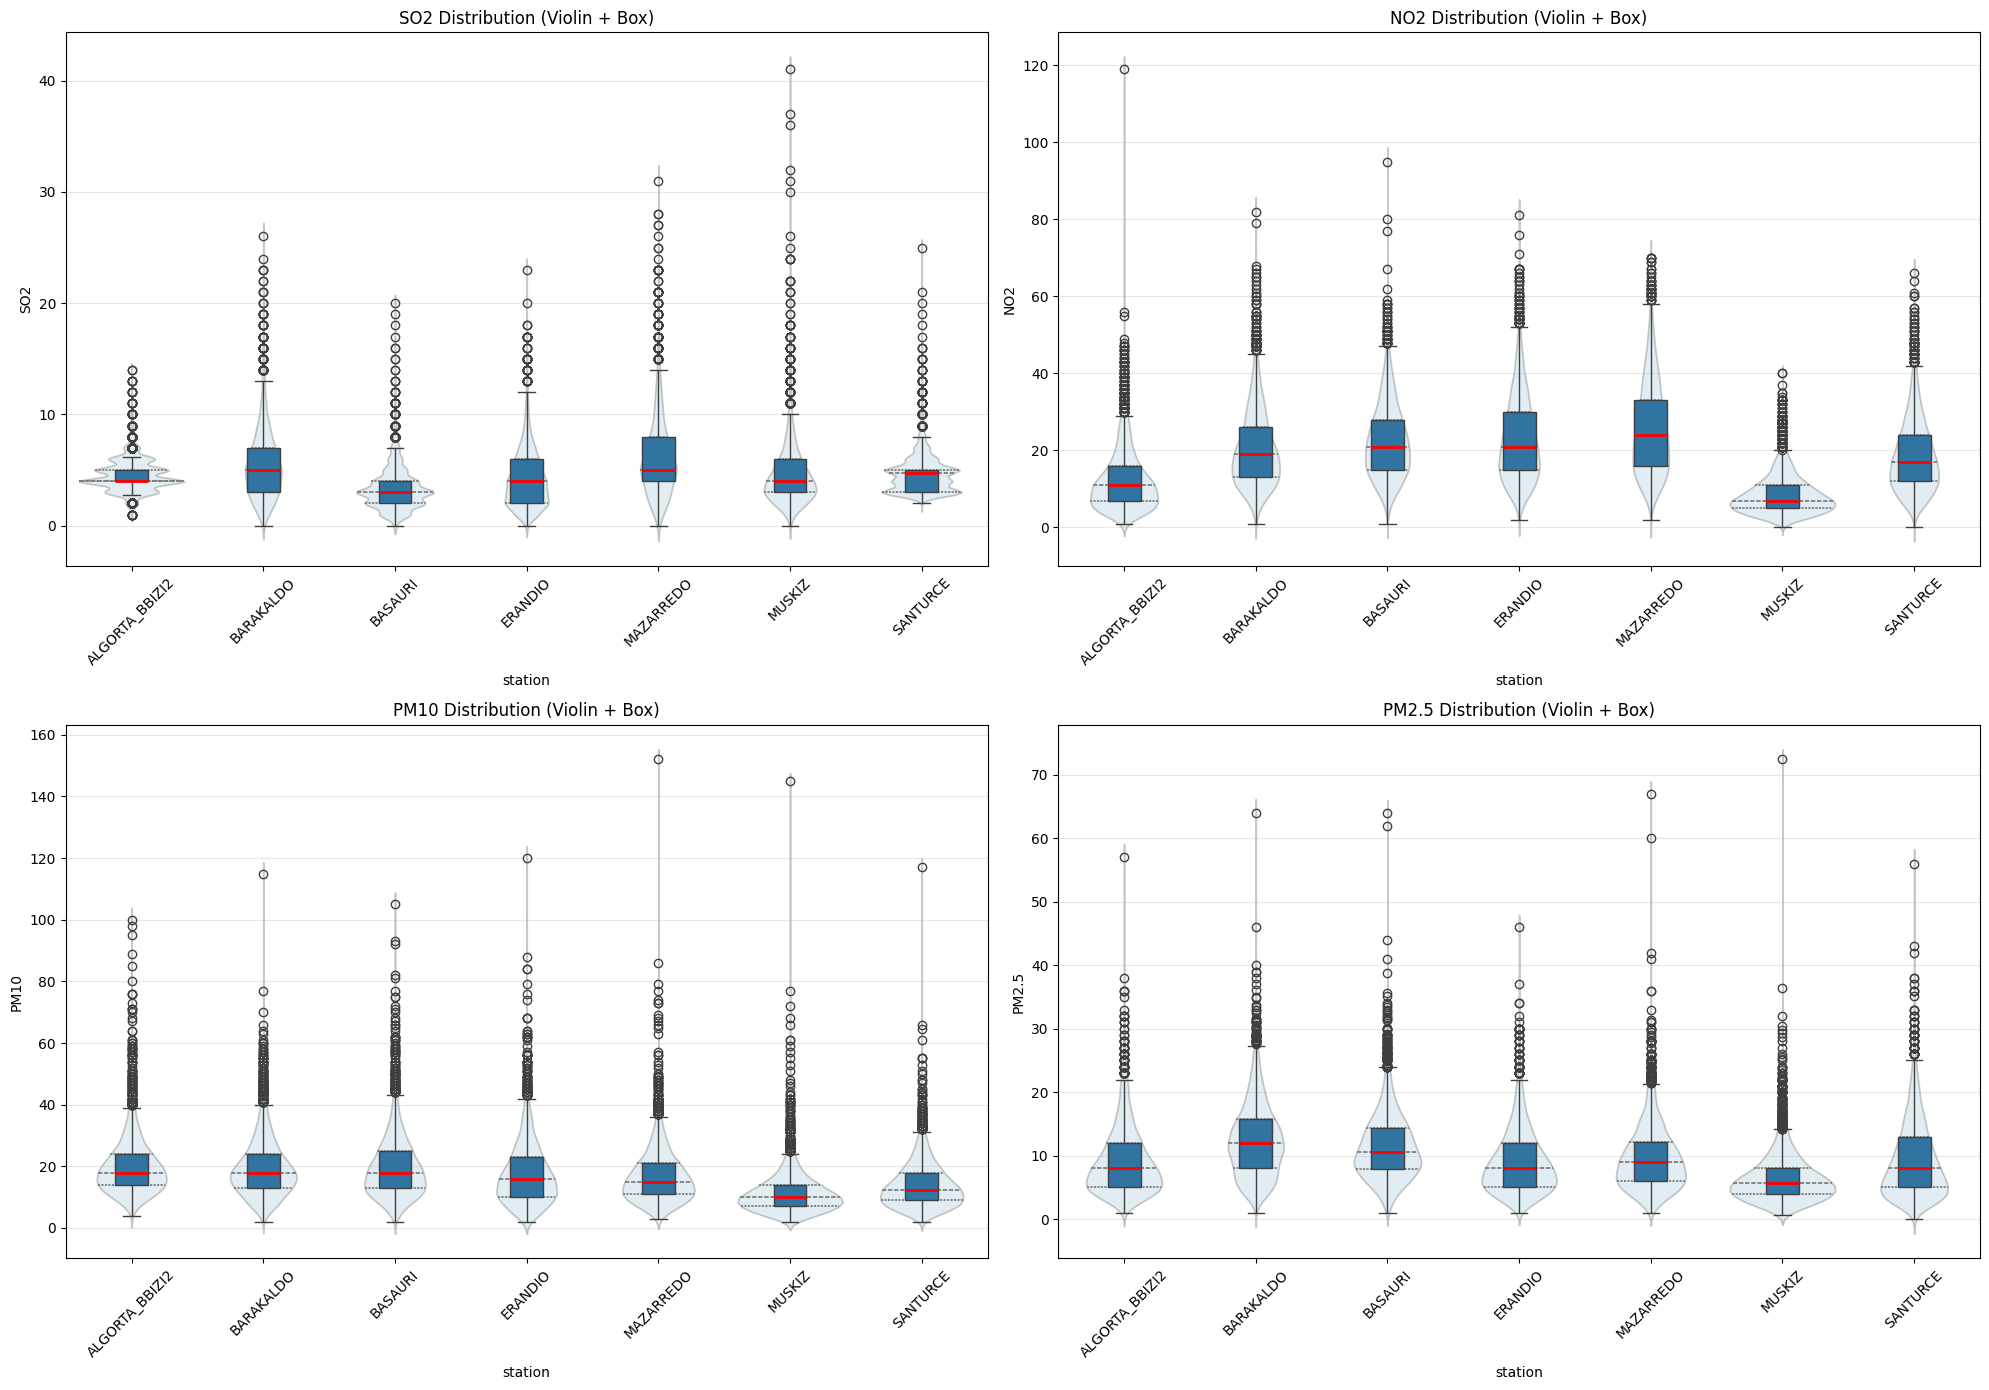

In [31]:
plt.figure(figsize=(20, 14))

for i, col in enumerate(pollutants, 1):
    plt.subplot(2, 2, i)

    # Violinplot (پس‌زمینه)
    sns.violinplot(
        data=df_final,
        x="station",
        y=col,
        inner="quartile",
        color="lightblue",
        alpha=0.4
    )

    # Boxplot (روی Violin)
    sns.boxplot(
        data=df_final,
        x="station",
        y=col,
        width=0.25,
        boxprops={"zorder": 3},
        whiskerprops={"zorder": 3},
        capprops={"zorder": 3},
        medianprops={"color": "red", "linewidth": 2, "zorder": 4}
    )

    plt.title(f"{col} Distribution (Violin + Box)")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


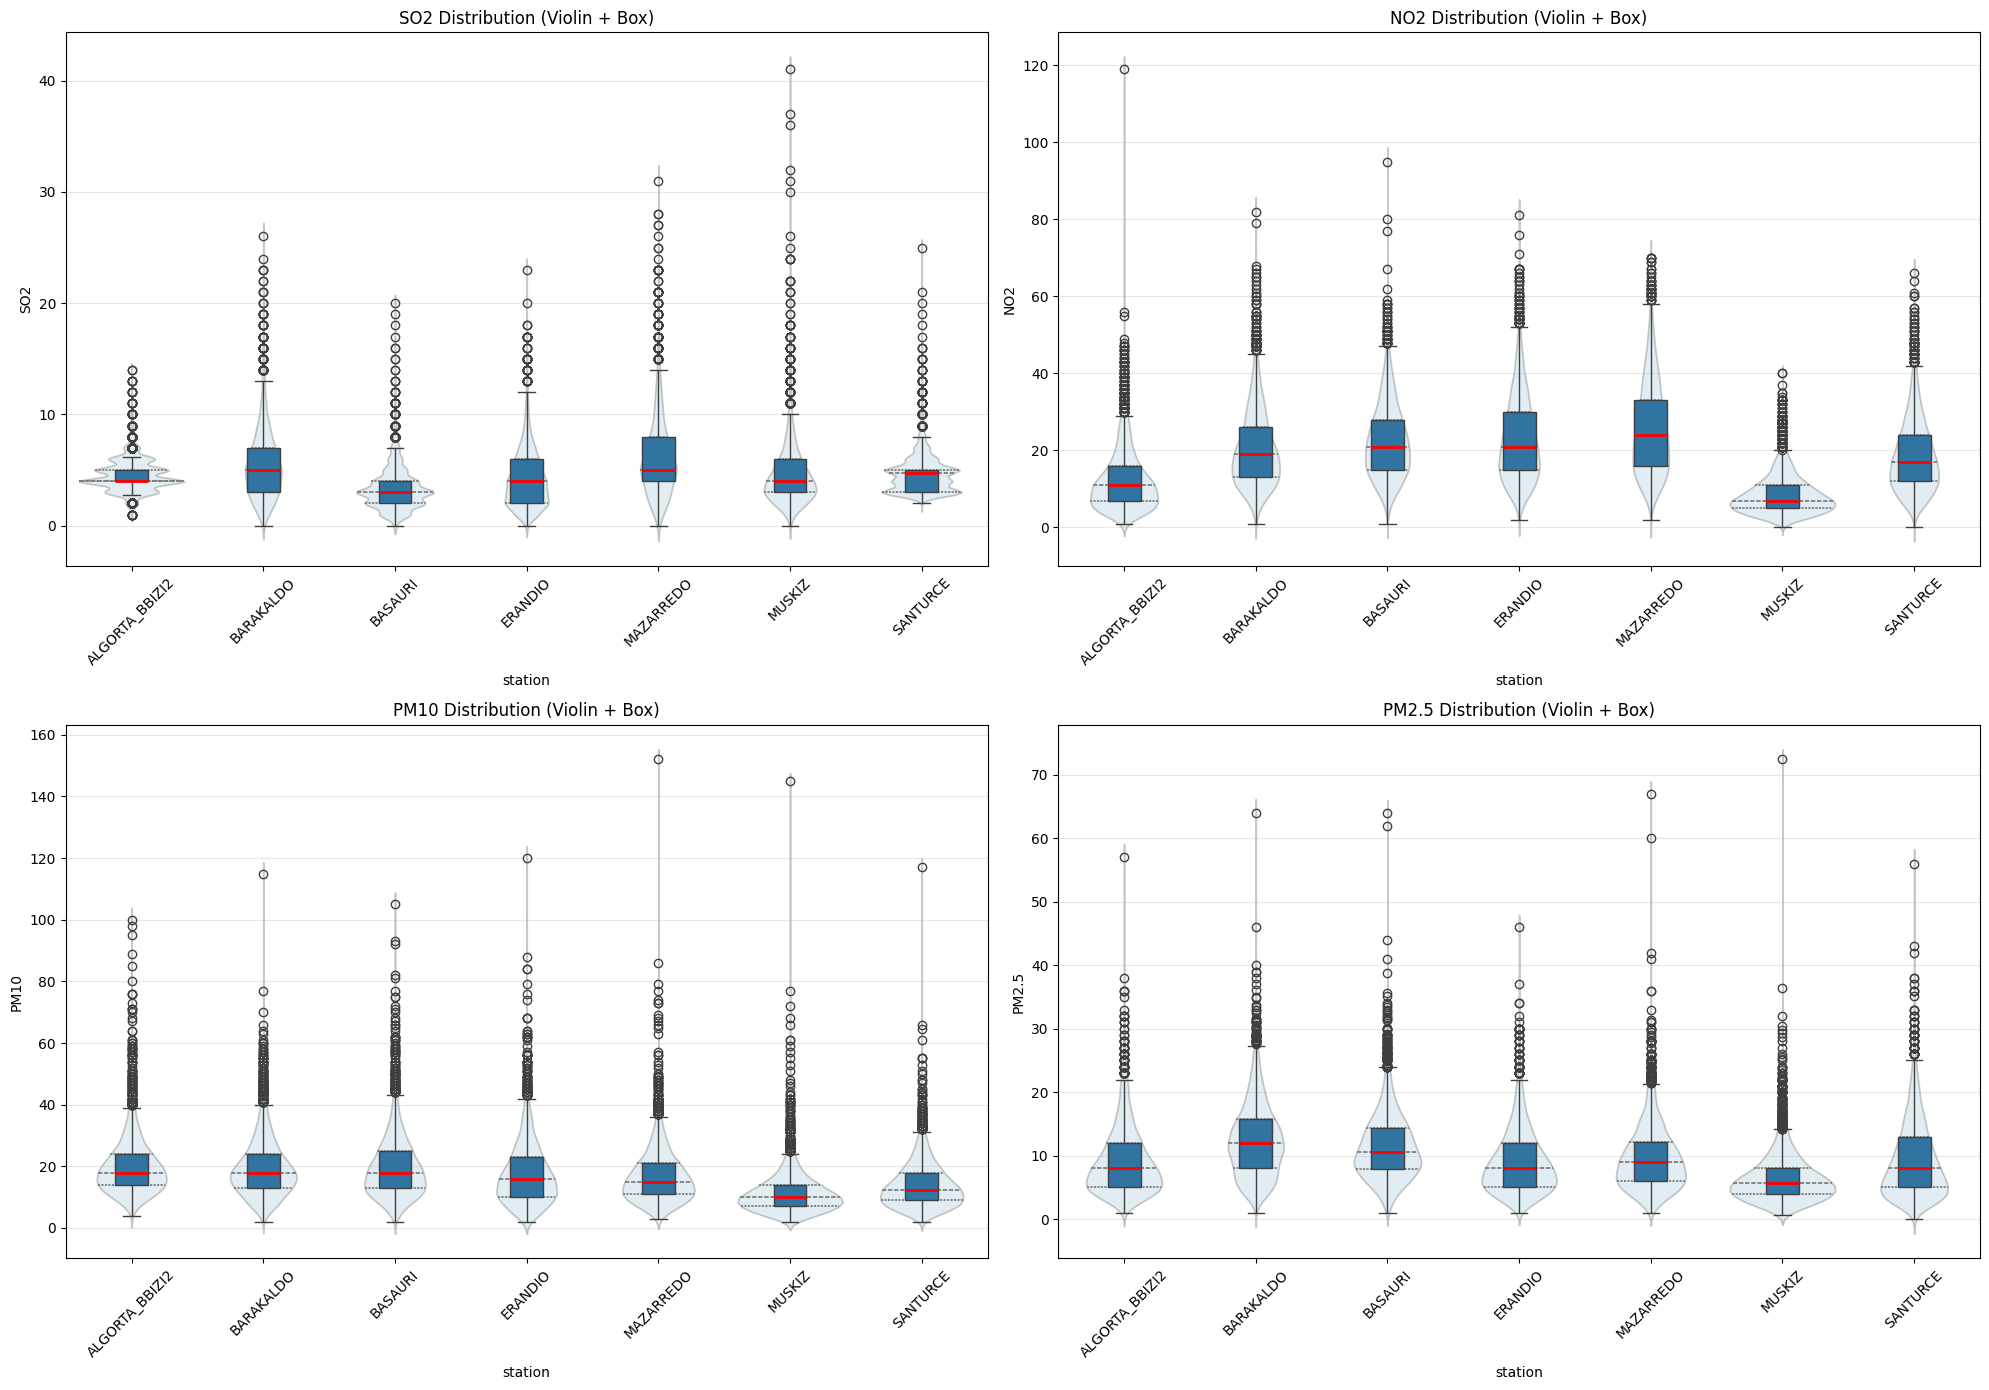

In [32]:
plt.figure(figsize=(20, 14))

for i, col in enumerate(pollutants, 1):
    plt.subplot(2, 2, i)

    # Violinplot (پس‌زمینه)
    sns.violinplot(
        data=df_final,
        x="station",
        y=col,
        inner="quartile",
        color="lightblue",
        alpha=0.4
    )

    # Boxplot (روی Violin)
    sns.boxplot(
        data=df_final,
        x="station",
        y=col,
        width=0.25,
        boxprops={"zorder": 3},
        whiskerprops={"zorder": 3},
        capprops={"zorder": 3},
        medianprops={"color": "red", "linewidth": 2, "zorder": 4}
    )

    plt.title(f"{col} Distribution (Violin + Box)")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


PM2.5 — Variabilidad moderada y tendencia descendente
Distribución relativamente estable entre estaciones, con valores más altos en zonas urbanas.

Disminución progresiva a lo largo de los años, indicando mejora en la calidad del aire.

Estacionalidad marcada: picos en invierno y mínimos en verano.

Pocos valores extremos, lo que refleja un comportamiento ambiental coherente.

PM10 — Mayor dispersión y fuerte influencia ambiental
Amplia variabilidad entre estaciones, especialmente en áreas urbanas y de tráfico.

Tendencia anual ligeramente descendente, pero con fluctuaciones notables.

Estacionalidad clara: incrementos en invierno y episodios puntuales por polvo sahariano.

Número elevado de outliers naturales debido a viento, obras y partículas gruesas.

NO2 — Comportamiento urbano y tendencia claramente decreciente
Concentraciones más altas en estaciones céntricas y de tráfico intenso.

Descenso sostenido en los últimos años, reflejando cambios en movilidad y políticas urbanas.

Distribución más compacta en estaciones costeras.

Pocos outliers, lo que indica un patrón muy estable y predecible.

SO2 — Niveles bajos con variabilidad industrial
Concentraciones generalmente reducidas en toda la red.

Variabilidad más visible en estaciones cercanas a zonas industriales o portuarias.

Tendencia anual estable, sin cambios bruscos.

Mayor número de outliers, típicos de emisiones puntuales industriales.

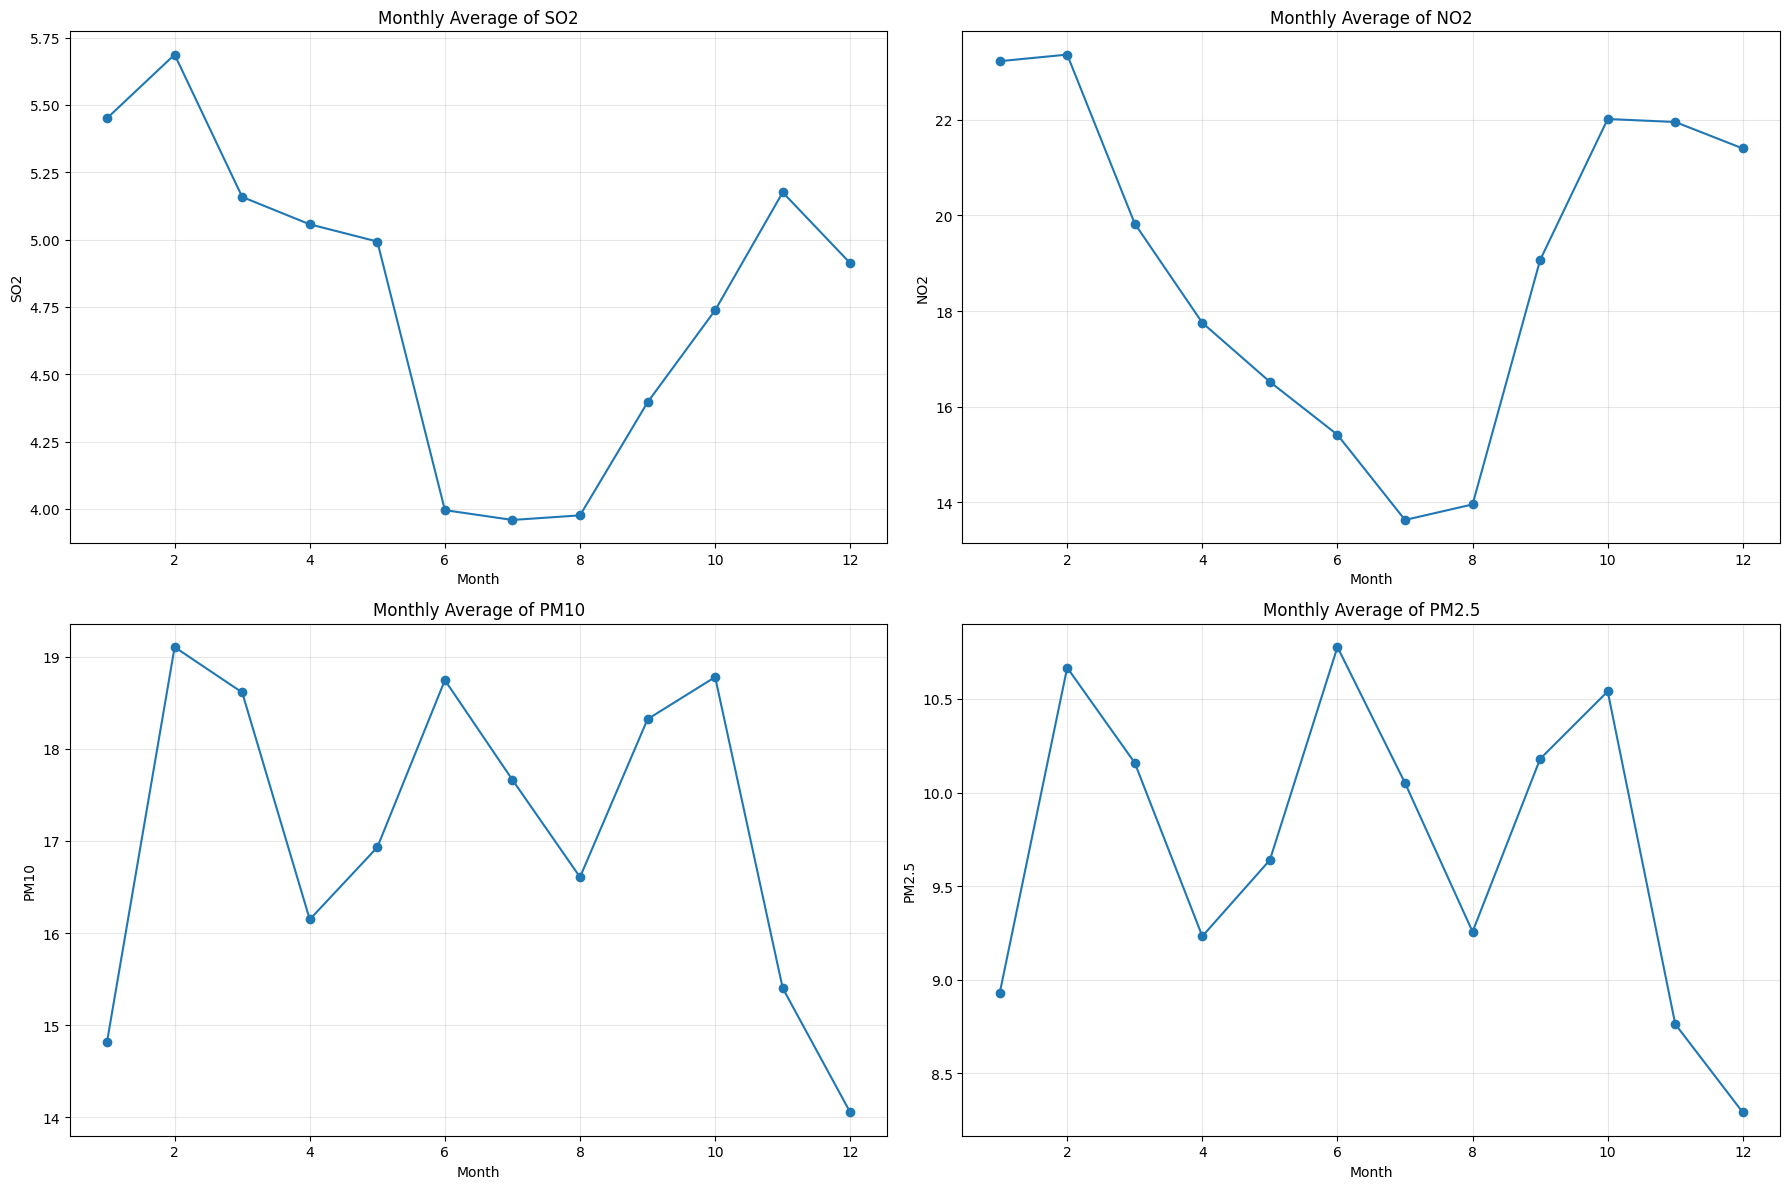

In [33]:
df_final["month"] = df_final["Date"].dt.month

plt.figure(figsize=(18, 12))

for i, col in enumerate(pollutants, 1):
    plt.subplot(2, 2, i)
    monthly = df_final.groupby("month")[col].mean()
    plt.plot(monthly.index, monthly.values, marker="o")
    plt.title(f"Monthly Average of {col}")
    plt.xlabel("Month")
    plt.ylabel(col)
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
outlier_summary = {}

for col in pollutants:
    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_final[(df_final[col] < lower) | (df_final[col] > upper)]

    outlier_summary[col] = len(outliers)

outlier_summary

{'SO2': 1203, 'NO2': 323, 'PM10': 694, 'PM2.5': 610}

In [35]:
outlier_station = {}

for col in pollutants:
    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_final[f"{col}_outlier"] = (df_final[col] < lower) | (df_final[col] > upper)

    outlier_station[col] = df_final.groupby("station")[f"{col}_outlier"].sum()

outlier_station

{'SO2': station
 ALGORTA_BBIZI2     20
 BARAKALDO         303
 BASAURI            32
 ERANDIO           123
 MAZARREDO         489
 MUSKIZ            177
 SANTURCE           59
 Name: SO2_outlier, dtype: int64,
 'NO2': station
 ALGORTA_BBIZI2      3
 BARAKALDO          38
 BASAURI            36
 ERANDIO            81
 MAZARREDO         144
 MUSKIZ              0
 SANTURCE           21
 Name: NO2_outlier, dtype: int64,
 'PM10': station
 ALGORTA_BBIZI2    126
 BARAKALDO         146
 BASAURI           164
 ERANDIO           138
 MAZARREDO          71
 MUSKIZ             26
 SANTURCE           23
 Name: PM10_outlier, dtype: int64,
 'PM2.5': station
 ALGORTA_BBIZI2     70
 BARAKALDO         181
 BASAURI           106
 ERANDIO            62
 MAZARREDO          69
 MUSKIZ             17
 SANTURCE          105
 Name: PM2.5_outlier, dtype: int64}

# Outliers
PM2.5 SANTURCE & BARAKALDO

PM10 BASAURI & BARAKALDO

SO2 MAZARREDO & BARAKALDO

NO2 MAZARREDO & ERANDIO

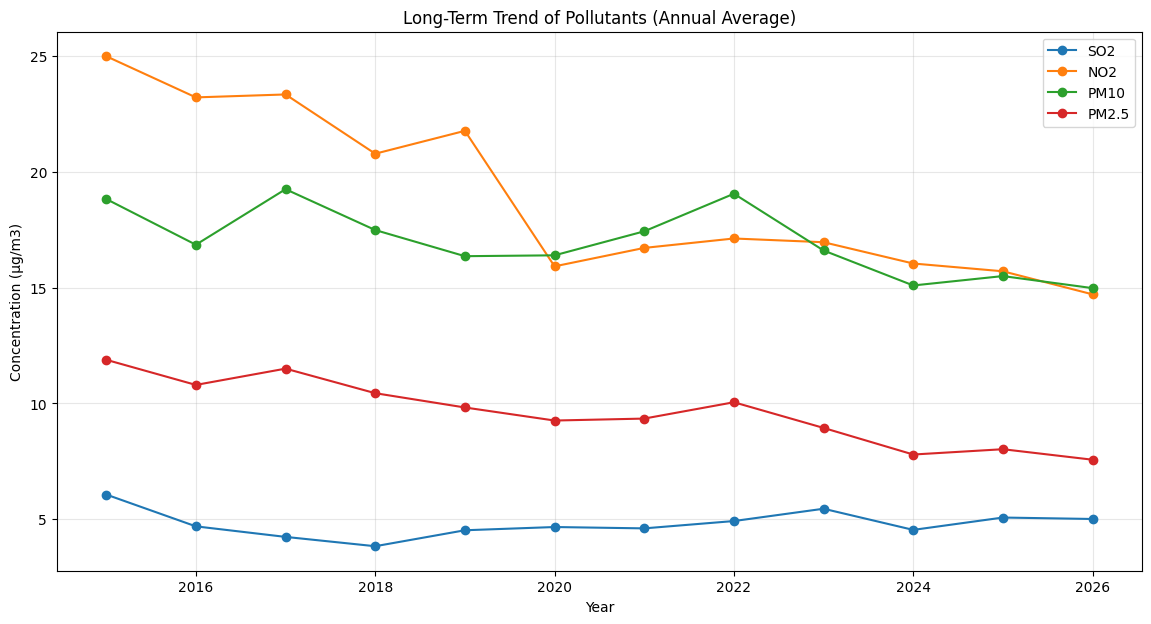

In [36]:
df_final["year"] = df_final["Date"].dt.year

annual = df_final.groupby("year")[pollutants].mean()

plt.figure(figsize=(14,7))
for col in pollutants:
    plt.plot(annual.index, annual[col], marker="o", label=col)

plt.title("Long-Term Trend of Pollutants (Annual Average)")
plt.xlabel("Year")
plt.ylabel("Concentration (µg/m3)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

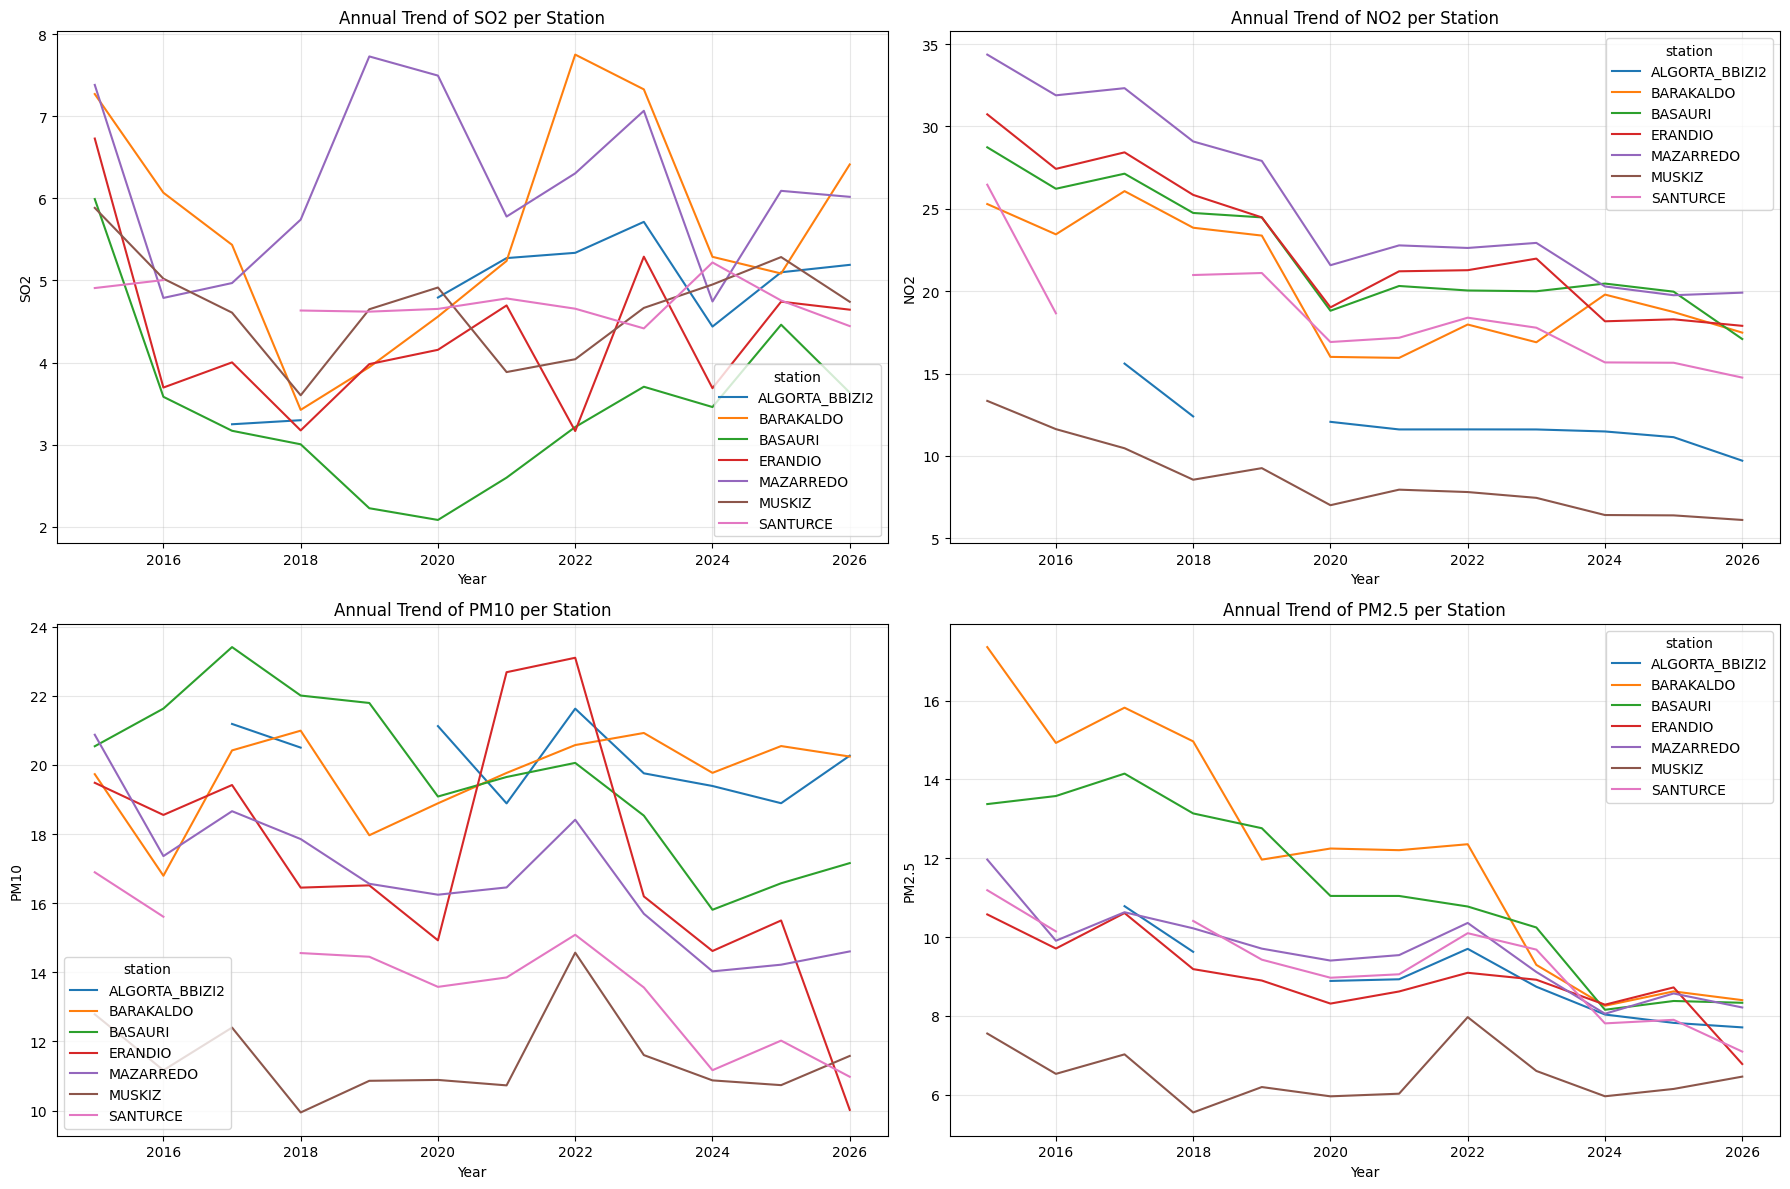

In [37]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(pollutants, 1):
    plt.subplot(2, 2, i)
    annual_station = df_final.groupby(["year", "station"])[col].mean().unstack()
    annual_station.plot(ax=plt.gca())
    plt.title(f"Annual Trend of {col} per Station")
    plt.xlabel("Year")
    plt.ylabel(col)
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

PM2.5 — Tendencia descendente y estable
Disminución suave y constante a lo largo de los años.

Valores más altos en invierno y más bajos en verano.

Estaciones urbanas muestran niveles más elevados que las costeras.

Indicador claro de mejora progresiva en la calidad del aire.

PM10 — Reducción moderada con fuerte estacionalidad
Descenso ligero pero continuo en la última década.

Variabilidad marcada por viento, obras y polvo sahariano.

Estaciones como BASAURI y BARAKALDO presentan los niveles más altos.

Estaciones costeras (MUSKIZ, SANTURTZI) mantienen valores bajos y estables.

NO2 — Disminución significativa y comportamiento muy urbano
Reducción notable a lo largo del tiempo, especialmente en zonas de tráfico.

Estaciones céntricas (MAZARREDO, ERANDIO) muestran picos más altos.

Tendencia general a la baja gracias a menor tráfico y políticas urbanas.

Patrón diario y anual muy marcado y predecible.

SO2 — Niveles bajos con variaciones industriales
Concentraciones generalmente bajas en toda la red.

Variabilidad asociada a actividad industrial y zonas portuarias.

Estaciones como MAZARREDO y MUSKIZ muestran fluctuaciones más visibles.

Tendencia global estable, sin cambios bruscos.

## COVID

In [38]:
df_final["year"] = df_final["Date"].dt.year

df_final["period"] = df_final["year"].apply(
    lambda y: "Before COVID" if y < 2020
    else ("During COVID" if y <= 2021 else "After COVID")
)

In [39]:
covid_compare = df_final.groupby("period")[pollutants].mean()
covid_compare

,SO2,NO2,PM10,PM2.5
period,,,,
After COVID,4.998920,16.316561,16.432913,8.611561
Before COVID,4.690546,22.823869,17.778079,10.908118
During COVID,4.635884,16.315481,16.911696,9.304125


<Figure size 1200x600 with 0 Axes>

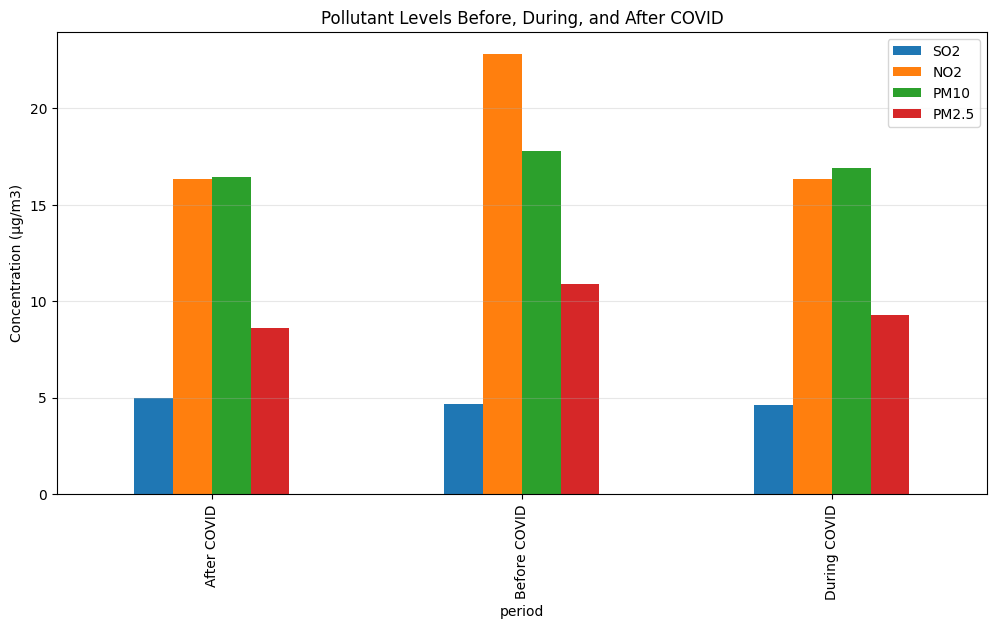

In [40]:
plt.figure(figsize=(12,6))
covid_compare.plot(kind="bar", figsize=(12,6))
plt.title("Pollutant Levels Before, During, and After COVID")
plt.ylabel("Concentration (µg/m3)")
plt.grid(axis="y", alpha=0.3)
plt.show()

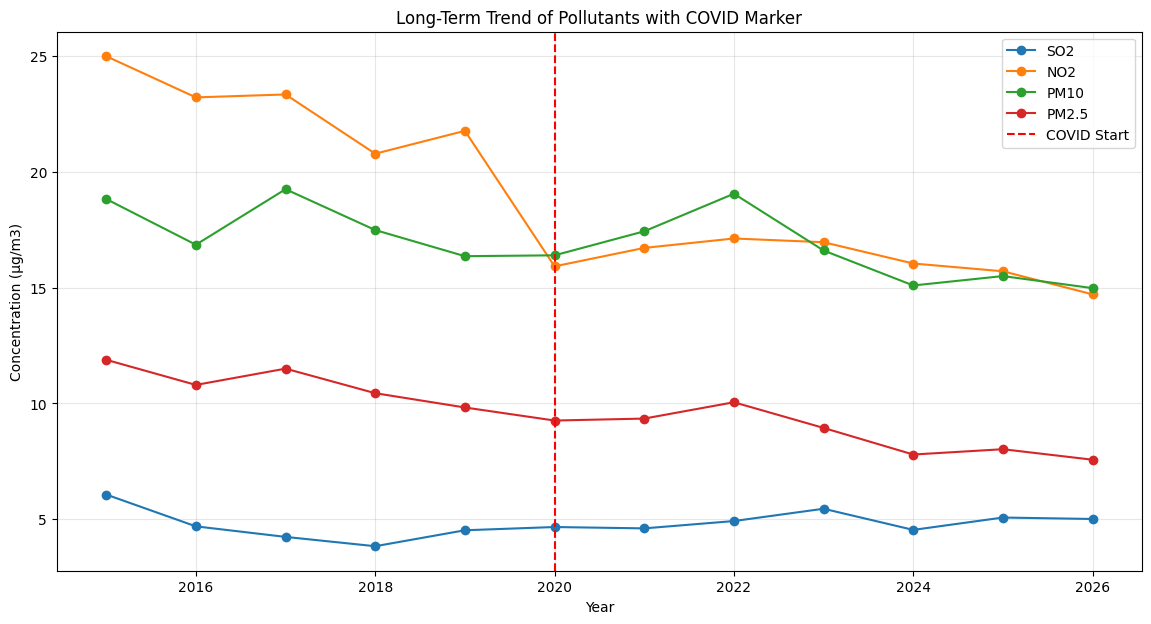

In [41]:
annual = df_final.groupby("year")[pollutants].mean()

plt.figure(figsize=(14,7))
for col in pollutants:
    plt.plot(annual.index, annual[col], marker="o", label=col)

plt.axvline(2020, color="red", linestyle="--", label="COVID Start")
plt.title("Long-Term Trend of Pollutants with COVID Marker")
plt.xlabel("Year")
plt.ylabel("Concentration (µg/m3)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

✔ PM2.5 → Disminución constante

✔ PM10 → Ligera disminución

✔ SO2 → Aumento tras la pandemia (solo aumenta el contaminante)

✔ NO2 → Disminución pronunciada durante la pandemia, recuperación incompleta

# Map